# Greater Sydney vibrancy index

## How to read this notebook

This notebook runs from top to bottom. The first half loads the 373 SA2s, builds the fourteen raw indicators, reconciles every input, checks the results, and saves the indicator and correlation tables. The second half builds the score and its sensitivity checks, adds the place types, hot spots, income groups and walking counts, and ends with the figures used in the story page. The index is a proxy for conditions that support street activity, not a direct measure of observed activity.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

from etl.load import connection_settings, engine
from index_tools import (
    assign_points_to_sa2s,
    assign_polygons_to_sa2s,
    classify_place_type,
    count_intersections,
    global_morans_i,
    local_morans_labels,
    local_morans_observed,
    local_morans_p_values,
    normalised_entropy,
    polygon_area_shares,
    score_index,
    standardised_score,
)

SCHEMA = "vibrancy"
SA2_CODE = "SA2_CODE21"
CRS_WGS84 = 4326
CRS_METRIC = 7856
MIN_BUSINESSES_FOR_ENTROPY = 10
INDUSTRY_CODES = list("ABCDEFGHIJKLMNOPQRS")
STREET_INDUSTRIES = ["G", "H", "R"]
HOME_BASED_INDUSTRIES = ["E", "I", "L", "M"]
LAND_USES = ["Commercial", "Education", "Hospital/Medical", "Parkland", "Residential"]
LINK_ROADS = ["trunk_link", "primary_link", "secondary_link", "tertiary_link"]
STOP_RULE = "location_type = 0"
G2_CROSSING_RULE = "crossing IN ('traffic_signals', 'marked', 'zebra') OR is_zebra"
DENSITY_COLUMNS = [
    "businesses_per_km2", "retail_arts_hospitality_per_km2", "stops_per_km2",
    "residents_per_ha", "shops_per_km2", "hospitals_per_km2",
    "amenities_per_km2", "traffic_lights_per_km2", "polling_places_per_km2",
    "school_catchments_per_km2", "intersections_per_km2", "crossings_per_km2",
]
INTENSITY_COLUMNS = DENSITY_COLUMNS[:10]
DIVERSITY_COLUMNS = ["industry_entropy", "land_use_entropy"]
DESIGN_COLUMNS = DENSITY_COLUMNS[10:]
INDICATOR_COLUMNS = INTENSITY_COLUMNS + DIVERSITY_COLUMNS + DESIGN_COLUMNS
Z_COLUMNS = [
    "z_i1_business_density", "z_i2_retail_arts_hospitality_density", "z_i3_stop_density",
    "z_i4_resident_density", "z_i5_shop_density", "z_i6_hospital_density",
    "z_i7_amenity_density", "z_i8_traffic_light_density", "z_i9_polling_place_density",
    "z_i10_school_density", "z_d1_industry_diversity", "z_d2_land_use_diversity",
    "z_g1_intersection_density", "z_g2_crossing_density",
]
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Load the SA2 frame

The boundary table defines the study area and supplies the published gross area used by every density. The database is only read.

In [2]:
database = engine(connection_settings())
boundaries = gpd.read_postgis(
    'SELECT "SA2_CODE21", "SA2_NAME21", "AREASQKM21", geom FROM vibrancy.sa2_boundaries ORDER BY "SA2_CODE21"',
    database,
    geom_col="geom",
    crs=CRS_WGS84,
)
boundaries[SA2_CODE] = boundaries[SA2_CODE].astype(int)
sa2_codes = boundaries[SA2_CODE]
indicators = pd.DataFrame({
    "sa2_code": sa2_codes,
    "sa2_name": boundaries["SA2_NAME21"],
    "area_km2": boundaries["AREASQKM21"],
}).set_index("sa2_code")
reconciliation_rows = []

assert len(boundaries) == 373, "The boundary table must contain 373 Greater Sydney SA2s"
display(indicators.head())
print(f"Loaded {len(indicators)} SA2s")

,sa2_name,area_km2
sa2_code,,
102011028,Avoca Beach - Copacabana,6.4376
102011029,Box Head - MacMasters Beach,32.0802
102011030,Calga - Kulnura,767.9512
102011031,Erina - Green Point,33.7934
102011032,Gosford - Springfield,16.9123


Loaded 373 SA2s


## 2. Record each input reconciliation

Each row keeps the source total, its allocation, and every stated reason for a dropped amount.

In [3]:
def add_reconciliation(dataset, features_in, assigned, no_location=0, outside_sa2=0,
                       mostly_outside=0, excluded_by_rule=0, no_sa2_overlap=0, note=""):
    """Add one checked row to the input reconciliation table."""
    dropped = no_location + outside_sa2 + mostly_outside + excluded_by_rule + no_sa2_overlap
    assert np.isclose(features_in, assigned + dropped), f"{dataset} does not reconcile"
    reconciliation_rows.append({
        "dataset": dataset, "features_in": features_in, "features_assigned": assigned,
        "no_location": no_location, "outside_373_sa2s": outside_sa2,
        "mostly_outside": mostly_outside, "excluded_by_rule": excluded_by_rule,
        "no_sa2_overlap": no_sa2_overlap, "features_dropped": dropped, "note": note,
    })

## 3. Add business density and industry diversity

The business source covers NSW, so only the 373 SA2 codes remain. Industry entropy is missing below the stated ten-business threshold.

In [4]:
businesses = pd.read_sql(
    'SELECT "SA2_CODE21", industry_code, total_businesses FROM vibrancy.businesses', database
)
businesses[SA2_CODE] = businesses[SA2_CODE].astype(int)
businesses_sydney = businesses[businesses[SA2_CODE].isin(sa2_codes)].copy()
business_totals = businesses_sydney.groupby(SA2_CODE)["total_businesses"].sum()
business_totals = business_totals.reindex(sa2_codes, fill_value=0)
street_totals = businesses_sydney[businesses_sydney["industry_code"].isin(STREET_INDUSTRIES)]
street_totals = street_totals.groupby(SA2_CODE)["total_businesses"].sum()
street_totals = street_totals.reindex(sa2_codes, fill_value=0)
industry_table = businesses_sydney.pivot_table(
    index=SA2_CODE, columns="industry_code", values="total_businesses", aggfunc="sum", fill_value=0
).reindex(index=sa2_codes, columns=INDUSTRY_CODES, fill_value=0)
industry_entropy = pd.Series(np.nan, index=sa2_codes, dtype=float)
for sa2_code, row in industry_table.iterrows():
    if row.sum() >= MIN_BUSINESSES_FOR_ENTROPY:
        industry_entropy.loc[sa2_code] = normalised_entropy(row.to_numpy(), len(INDUSTRY_CODES))

add_reconciliation("businesses", len(businesses), len(businesses_sydney),
                   outside_sa2=len(businesses) - len(businesses_sydney),
                   note="NSW rows outside Greater Sydney")
display(industry_table.head())
print(f"Industry entropy is missing for {industry_entropy.isna().sum()} SA2s")

industry_code,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S
SA2_CODE21,,,,,,,,,,,,,,,,,,,
102011028,7,3,13,4,194,26,47,27,15,20,40,78,138,44,0,19,79,21,33
102011029,21,0,26,3,265,21,45,32,30,13,41,103,218,61,0,19,59,31,39
102011030,223,20,98,8,186,78,59,35,53,8,44,191,95,30,0,24,50,24,44
102011031,17,0,55,3,280,55,161,85,48,20,125,209,264,75,7,52,232,28,91
102011032,16,7,150,11,364,95,182,120,175,36,96,318,338,129,13,53,335,47,144


Industry entropy is missing for 7 SA2s


## 4. Add resident density

Population is already coded to the study SA2s, so no spatial join is needed.

In [5]:
population = pd.read_sql(
    'SELECT "SA2_CODE21", total_people FROM vibrancy.population', database
).set_index(SA2_CODE)
population.index = population.index.astype(int)
population = population.reindex(sa2_codes)

add_reconciliation("population", len(population), population["total_people"].notna().sum())
display(population.head())
print(f"Population total: {population['total_people'].sum():,}")

,total_people
SA2_CODE21,
102011028,7578
102011029,11289
102011030,4678
102011031,14644
102011032,23282


Population total: 5,638,830


## 5. Add land-use diversity

Only the five stated land-use categories contribute to D2. Entropy is missing when fewer than two categories have area.

In [6]:
mesh_blocks = pd.read_sql(
    'SELECT "SA2_CODE21", category, area_sqkm FROM vibrancy.mesh_blocks', database
)
mesh_blocks[SA2_CODE] = mesh_blocks[SA2_CODE].astype(int)
land_use_table = mesh_blocks[mesh_blocks["category"].isin(LAND_USES)].pivot_table(
    index=SA2_CODE, columns="category", values="area_sqkm", aggfunc="sum", fill_value=0
).reindex(index=sa2_codes, columns=LAND_USES, fill_value=0)
land_use_entropy = pd.Series(np.nan, index=sa2_codes, dtype=float)
for sa2_code, row in land_use_table.iterrows():
    if (row > 0).sum() >= 2:
        land_use_entropy.loc[sa2_code] = normalised_entropy(row.to_numpy(), len(LAND_USES))

add_reconciliation("mesh blocks", len(mesh_blocks), len(mesh_blocks))
display(land_use_table.head())
print(f"Land-use entropy is missing for {land_use_entropy.isna().sum()} SA2s")

category,Commercial,Education,Hospital/Medical,Parkland,Residential
SA2_CODE21,,,,,
102011028,0.0519,0.0471,0.0000,1.3525,4.3512
102011029,0.0000,0.0671,0.0000,15.4499,11.8458
102011030,0.3643,0.1611,0.0000,521.5638,5.9183
102011031,0.8260,0.4201,0.1580,7.8873,13.8536
102011032,1.5174,0.3549,0.1288,5.5979,7.2599


Land-use entropy is missing for 10 SA2s


## 6. Combine the coded-SA2 indicators

Published SA2 area is the denominator for the density indicators.

In [7]:
area_km2 = indicators["area_km2"]
indicators["residents"] = population["total_people"]
indicators["businesses"] = business_totals
indicators["businesses_per_km2"] = business_totals / area_km2
indicators["retail_arts_hospitality_per_km2"] = street_totals / area_km2
indicators["residents_per_ha"] = population["total_people"] / (area_km2 * 100)
indicators["industry_entropy"] = industry_entropy
indicators["land_use_entropy"] = land_use_entropy

display(indicators[[
    "residents", "businesses", "businesses_per_km2", "retail_arts_hospitality_per_km2",
    "residents_per_ha", "industry_entropy", "land_use_entropy",
]].head())

,residents,businesses,businesses_per_km2,retail_arts_hospitality_per_km2,residents_per_ha,industry_entropy,land_use_entropy
sa2_code,,,,,,,
102011028,7578,808,125.512613,14.757052,11.771468,0.824658,0.395527
102011029,11289,1027,32.013516,3.366563,3.518993,0.796798,0.434882
102011030,4678,1270,1.653751,0.153656,0.060915,0.861585,0.043469
102011031,14644,1807,53.471980,8.108092,4.333391,0.852820,0.559085
102011032,23282,2629,155.448993,20.635869,13.766312,0.875651,0.671707


## 7. Prepare the point assignment rule

Points in a database table are assigned to SA2s in SQL, one query per table. A point on a shared boundary keeps the lower SA2 code. A point with no location, or one outside the 373 SA2s, keeps a NULL SA2 code, so the reconciliation table can count it separately. The street intersections in section 18 are derived in Python, so they use the matching Python function.

In [8]:
POINT_COUNT_SQL = """
WITH points AS (
    SELECT row_number() OVER () AS point_id,
           geom,
           (geom IS NULL OR ST_IsEmpty(geom)) AS no_location
    FROM {schema}.{table}
    WHERE ({rule})
),
assigned AS (
    -- A point on a shared boundary touches two SA2s, so keep the lower SA2 code.
    -- A point in no SA2, or with no location, keeps a NULL SA2 code.
    SELECT DISTINCT ON (points.point_id)
           points.point_id, sa2."SA2_CODE21", points.no_location
    FROM points
    LEFT JOIN {schema}.sa2_boundaries AS sa2 ON ST_Intersects(sa2.geom, points.geom)
    ORDER BY points.point_id, sa2."SA2_CODE21"
)
SELECT "SA2_CODE21", no_location, COUNT(*) AS point_count
FROM assigned
GROUP BY "SA2_CODE21", no_location
"""


def count_points_per_sa2(table, rule="TRUE"):
    """Return the zero-filled point count per SA2, the rows with no location, and the rows in no SA2."""
    sql = POINT_COUNT_SQL.format(schema=SCHEMA, table=table, rule=rule)
    result = pd.read_sql(sql, database)
    has_sa2 = result[SA2_CODE].notna()
    counts = result[has_sa2].set_index(SA2_CODE)["point_count"]
    counts.index = counts.index.astype(int)
    counts = counts.reindex(sa2_codes, fill_value=0)
    no_location = result.loc[result["no_location"], "point_count"].sum()
    outside_sa2 = result.loc[~has_sa2 & ~result["no_location"], "point_count"].sum()
    return counts, no_location, outside_sa2


def assign_table_points(label, table, rule="TRUE", features_in=None, extra_no_location=0,
                        excluded_by_rule=0, note=""):
    """Count one table's points per SA2 in SQL, add its reconciliation row, and return the counts."""
    counts, no_location, outside_sa2 = count_points_per_sa2(table, rule)
    if features_in is None:
        row_count_sql = f"SELECT COUNT(*) AS row_count FROM {SCHEMA}.{table} WHERE ({rule})"
        features_in = pd.read_sql(row_count_sql, database)["row_count"].iloc[0]
    add_reconciliation(label, features_in, counts.sum(), no_location=no_location + extra_no_location,
                       outside_sa2=outside_sa2, excluded_by_rule=excluded_by_rule, note=note)
    return counts

## 8. Assign stops

Only stop and platform rows, location type 0, contribute to I3. Other valid location types remain visible as a rule exclusion.

In [9]:
stop_rows = pd.read_sql(f"""
    SELECT COUNT(*) AS all_rows,
           COUNT(*) FILTER (WHERE geom IS NULL OR ST_IsEmpty(geom)) AS no_location,
           COUNT(*) FILTER (WHERE NOT ({STOP_RULE})
                            AND NOT (geom IS NULL OR ST_IsEmpty(geom))) AS excluded_by_rule
    FROM {SCHEMA}.stops
""", database).iloc[0]
stop_counts = assign_table_points(
    "stops", "stops", rule=STOP_RULE, features_in=stop_rows["all_rows"],
    extra_no_location=stop_rows["no_location"], excluded_by_rule=stop_rows["excluded_by_rule"],
    note="Only location type 0 contributes to I3",
)
indicators["stops_per_km2"] = stop_counts / area_km2
print(f"Assigned stop and platform rows: {stop_counts.sum():,}")
display(indicators[["stops_per_km2"]].head())

Assigned stop and platform rows: 31,793


,stops_per_km2
sa2_code,
102011028,10.096931
102011029,3.553594
102011030,0.144540
102011031,4.468328
102011032,11.470941


## 9. Assign daily-living shops

All loaded shop rows contribute to I5, including petrol stations.

In [10]:
shop_counts = assign_table_points("daily living shops", "daily_living_shops")
indicators["shops_per_km2"] = shop_counts / area_km2
petrol_counts, _, _ = count_points_per_sa2("daily_living_shops", rule="amenity = 'fuel'")
petrol_inside = petrol_counts.sum()
assert petrol_inside == 931, "The petrol-station count differs from the documented count"
print(f"Petrol stations assigned inside Greater Sydney: {petrol_inside:,}")
display(indicators[["shops_per_km2"]].head())

Petrol stations assigned inside Greater Sydney: 931


,shops_per_km2
sa2_code,
102011028,0.310675
102011029,0.062344
102011030,0.013022
102011031,0.355099
102011032,0.768671


## 10. Assign hospitals

Hospitals with no assigned point count as zero for their SA2.

In [11]:
hospital_counts = assign_table_points("hospitals", "hospitals")
indicators["hospitals_per_km2"] = hospital_counts / area_km2
print(f"Assigned hospitals: {hospital_counts.sum():,}")
display(indicators[["hospitals_per_km2"]].head())

Assigned hospitals: 164


,hospitals_per_km2
sa2_code,
102011028,0.000000
102011029,0.000000
102011030,0.000000
102011031,0.029592
102011032,0.177386


## 11. Assign public amenities

Toilets and drinking-water points are combined for I7.

In [12]:
amenity_counts = assign_table_points("public amenities", "public_amenities")
indicators["amenities_per_km2"] = amenity_counts / area_km2
print(f"Assigned amenities: {amenity_counts.sum():,}")
display(indicators[["amenities_per_km2"]].head())

Assigned amenities: 4,507


,amenities_per_km2
sa2_code,
102011028,1.087362
102011029,0.436406
102011030,0.016928
102011031,0.059183
102011032,0.827800


## 12. Assign traffic lights

Rows with no location are dropped and recorded in the reconciliation table.

In [13]:
traffic_light_counts = assign_table_points("traffic lights", "traffic_lights")
indicators["traffic_lights_per_km2"] = traffic_light_counts / area_km2
print(f"Assigned traffic lights: {traffic_light_counts.sum():,}")
display(indicators[["traffic_lights_per_km2"]].head())

Assigned traffic lights: 3,653


,traffic_lights_per_km2
sa2_code,
102011028,0.000000
102011029,0.062344
102011030,0.019532
102011031,0.503057
102011032,1.537343


## 13. Assign polling places

Rows with no location are dropped and recorded in the reconciliation table.

In [14]:
polling_place_counts = assign_table_points("polling places", "polling_places")
indicators["polling_places_per_km2"] = polling_place_counts / area_km2
print(f"Assigned polling places: {polling_place_counts.sum():,}")
display(indicators[["polling_places_per_km2"]].head())

Assigned polling places: 1,557


,polling_places_per_km2
sa2_code,
102011028,0.310675
102011029,0.062344
102011030,0.009115
102011031,0.236733
102011032,0.354771


## 14. Assign crossings

The reconciliation keeps all crossing types, while G2 uses only signalised, marked, zebra, or explicitly zebra-tagged rows.

In [15]:
all_crossing_counts = assign_table_points("crossings, all kinds", "crossings")
crossing_counts = assign_table_points("crossings, G2 rule", "crossings", rule=G2_CROSSING_RULE)
indicators["crossings_per_km2"] = crossing_counts / area_km2
print(f"Assigned G2 crossings: {crossing_counts.sum():,}")
display(indicators[["crossings_per_km2"]].head())

Assigned G2 crossings: 20,154


,crossings_per_km2
sa2_code,
102011028,0.776687
102011029,0.124688
102011030,0.007813
102011031,2.781608
102011032,10.229241


The SQL rule should agree with the tested Python rule. This check assigns every crossing with `assign_points_to_sa2s` from `index_tools.py`, which has small hand-checkable tests, and compares the counts per SA2 with the SQL counts.

In [16]:
crossing_points = gpd.read_postgis(
    f"SELECT geom FROM {SCHEMA}.crossings", database, geom_col="geom", crs=CRS_WGS84
)
python_assigned = assign_points_to_sa2s(crossing_points, boundaries)
python_counts = python_assigned.value_counts().reindex(sa2_codes, fill_value=0).astype(int)
assert (python_counts.to_numpy() == all_crossing_counts.to_numpy()).all(), "SQL and Python assign crossings differently"
print(f"SQL and Python put the same {python_counts.sum():,} crossings in the same SA2s")

SQL and Python put the same 78,949 crossings in the same SA2s


## 15. Check the documented point totals

The expected inside counts and the number of SA2s with no feature are checked before scoring.

In [17]:
point_checks = pd.DataFrame({
    "assigned": [stop_counts.sum(), traffic_light_counts.sum(), polling_place_counts.sum(),
                 hospital_counts.sum(), amenity_counts.sum(), shop_counts.sum(),
                 all_crossing_counts.sum(), crossing_counts.sum()],
    "expected_assigned": [31793, 3653, 1557, 164, 4507, 3034, 78949, 20154],
    "zero_sa2s": [(stop_counts == 0).sum(), (traffic_light_counts == 0).sum(),
                  (polling_place_counts == 0).sum(), (hospital_counts == 0).sum(),
                  (amenity_counts == 0).sum(), (shop_counts == 0).sum(),
                  (all_crossing_counts == 0).sum(), (crossing_counts == 0).sum()],
    "expected_zero_sa2s": [1, 18, 19, 278, 27, 20, 3, 6],
}, index=["stops", "traffic lights", "polling places", "hospitals", "public amenities",
          "daily living shops", "crossings, all kinds", "crossings, G2 rule"])
point_checks["assigned_difference"] = point_checks["assigned"] - point_checks["expected_assigned"]
point_checks["zero_sa2_difference"] = point_checks["zero_sa2s"] - point_checks["expected_zero_sa2s"]
assert (point_checks[["assigned_difference", "zero_sa2_difference"]] == 0).all().all(), "Point counts differ from the documented totals"
display(point_checks)

,assigned,expected_assigned,zero_sa2s,expected_zero_sa2s,assigned_difference,zero_sa2_difference
stops,31793,31793,1,1,0,0
traffic lights,3653,3653,18,18,0,0
polling places,1557,1557,19,19,0,0
hospitals,164,164,278,278,0,0
public amenities,4507,4507,27,27,0,0
daily living shops,3034,3034,20,20,0,0
"crossings, all kinds",78949,78949,3,3,0,0
"crossings, G2 rule",20154,20154,6,6,0,0


## 16. Allocate school catchments by area share

Each catchment contributes a fractional count to every SA2 it overlaps. The part outside the 373 SA2s is recorded as a dropped catchment equivalent.

In [18]:
schools = gpd.read_postgis(
    'SELECT "USE_ID", "CATCH_TYPE", geom FROM vibrancy.schools',
    database, geom_col="geom", crs=CRS_WGS84,
)
school_area_shares = polygon_area_shares(schools, boundaries, metric_crs=CRS_METRIC)
share_totals = school_area_shares.groupby("source_index")["area_share"].sum()
share_totals = share_totals.reindex(schools.index, fill_value=0.0)
assert (share_totals <= 1 + 1e-9).all(), "School area shares cannot exceed one catchment"
area_share_counts = school_area_shares.groupby("assigned_sa2")["area_share"].sum()
area_share_counts = area_share_counts.reindex(sa2_codes, fill_value=0.0)
indicators["school_catchments_per_km2"] = area_share_counts / area_km2

school_touches = share_totals > 0
school_shares_assigned = school_area_shares["area_share"].sum()
school_shares_outside = (1 - share_totals[school_touches]).sum()
school_no_overlap = (~school_touches).sum()
add_reconciliation(
    "school catchments", len(schools), school_shares_assigned, outside_sa2=school_shares_outside,
    no_sa2_overlap=school_no_overlap, note="Area-share allocation for I10",
)
print(f"Assigned school catchment equivalents: {school_shares_assigned:.3f}")
print(f"Outside catchment equivalents: {school_shares_outside:.3f}")
print(f"Catchments with no SA2 overlap: {school_no_overlap:,}")
display(indicators[["school_catchments_per_km2"]].head())

Assigned school catchment equivalents: 907.763
Outside catchment equivalents: 49.237
Catchments with no SA2 overlap: 1,157


,school_catchments_per_km2
sa2_code,
102011028,0.219276
102011029,0.091291
102011030,0.011655
102011031,0.105130
102011032,0.181634


## 17. Keep the largest-overlap school diagnostic

The original allocation remains a checked diagnostic and a sensitivity alternative.

In [19]:
school_largest_assignment = assign_polygons_to_sa2s(schools, boundaries, metric_crs=CRS_METRIC)
school_largest_counts = school_largest_assignment["assigned_sa2"].value_counts()
school_largest_counts = school_largest_counts.reindex(sa2_codes, fill_value=0).astype(int)

school_metric = schools.to_crs(CRS_METRIC).copy()
school_metric.geometry = school_metric.geometry.make_valid()
representative_points = school_metric.copy()
representative_points.geometry = representative_points.geometry.representative_point()
representative_points = representative_points.to_crs(CRS_WGS84)
representative_sa2 = assign_points_to_sa2s(representative_points, boundaries)
assigned_school = school_largest_assignment["assigned_sa2"].notna()
different_representative = (
    representative_sa2.fillna(-1)[assigned_school] != school_largest_assignment.loc[assigned_school, "assigned_sa2"]
).sum()

touches_sydney = school_largest_assignment["n_sa2_touched"] > 0
mostly_outside = touches_sydney & school_largest_assignment["assigned_sa2"].isna()
school_checks = pd.Series({
    "catchments_touching_greater_sydney": int(touches_sydney.sum()),
    "touching_three_or_more_sa2s": int((school_largest_assignment["n_sa2_touched"] >= 3).sum()),
    "winner_at_least_half": int((touches_sydney & (school_largest_assignment["winner_share"] >= 0.5)).sum()),
    "median_winner_share": float(school_largest_assignment.loc[touches_sydney, "winner_share"].median()),
    "weak_winner_under_30_percent": int((touches_sydney & (school_largest_assignment["winner_share"] < 0.3)).sum()),
    "mostly_outside": int(mostly_outside.sum()),
    "assigned": int(assigned_school.sum()),
    "different_representative_point": int(different_representative),
    "rows_sharing_school_id": int(schools["USE_ID"].duplicated(keep=False).sum()),
})
expected_school_checks = pd.Series({
    "catchments_touching_greater_sydney": 957, "touching_three_or_more_sa2s": 772,
    "winner_at_least_half": 727, "median_winner_share": 0.69,
    "weak_winner_under_30_percent": 73, "mostly_outside": 42, "assigned": 915,
    "different_representative_point": 135, "rows_sharing_school_id": 156,
})
school_comparison = pd.DataFrame({"actual": school_checks, "expected": expected_school_checks})
school_comparison["difference"] = school_comparison["actual"] - school_comparison["expected"]
integer_school_checks = school_comparison.drop(index="median_winner_share")
assert (integer_school_checks["difference"] == 0).all(), "Largest-overlap school counts differ from the documented counts"
assert abs(school_checks["median_winner_share"] - 0.69) < 0.005, "School median share differs from the documented rounded value"
display(school_comparison)

,actual,expected,difference
catchments_touching_greater_sydney,957.000000,957.00,0.000000
touching_three_or_more_sa2s,772.000000,772.00,0.000000
winner_at_least_half,727.000000,727.00,0.000000
median_winner_share,0.687697,0.69,-0.002303
weak_winner_under_30_percent,73.000000,73.00,0.000000
mostly_outside,42.000000,42.00,0.000000
assigned,915.000000,915.00,0.000000
different_representative_point,135.000000,135.00,0.000000
rows_sharing_school_id,156.000000,156.00,0.000000


## 18. Derive street intersections

Road-link classes are removed. Vertices with at least three combined road legs become points and follow the same SA2 assignment rule.

In [20]:
def assign_point_dataset(label, points, features_in=None, extra_no_location=0,
                         excluded_by_rule=0, note=""):
    """Assign points, reconcile them, and return a zero-filled SA2 count."""
    assigned = assign_points_to_sa2s(points, boundaries)
    no_location = (points.geometry.isna() | points.geometry.is_empty).sum() + extra_no_location
    outside = (assigned.isna() & points.geometry.notna() & ~points.geometry.is_empty).sum()
    counts = assigned.value_counts().reindex(sa2_codes, fill_value=0).astype(int)
    input_count = len(points) if features_in is None else features_in
    add_reconciliation(label, input_count, assigned.notna().sum(), no_location=no_location,
                       outside_sa2=outside, excluded_by_rule=excluded_by_rule, note=note)
    return counts, assigned

In [21]:
roads = gpd.read_postgis(
    'SELECT highway, geom FROM vibrancy.roads', database, geom_col="geom", crs=CRS_WGS84
)
roads_for_intersections = roads[~roads["highway"].isin(LINK_ROADS)].copy()
add_reconciliation("roads", len(roads), len(roads_for_intersections),
                   excluded_by_rule=len(roads) - len(roads_for_intersections),
                   note="Link classes excluded before deriving intersections")
intersections = count_intersections(roads_for_intersections, precision=7, min_legs=3)
intersection_counts, _ = assign_point_dataset("derived intersections", intersections)
indicators["intersections_per_km2"] = intersection_counts / area_km2
print(f"Kept {len(roads_for_intersections):,} of {len(roads):,} road lines")
print(f"Derived {len(intersections):,} intersections; {intersection_counts.sum():,} fall in the 373 SA2s")
display(intersections["legs"].describe())

Kept 147,523 of 150,623 road lines
Derived 110,518 intersections; 101,133 fall in the 373 SA2s


count    110518.000000
mean          3.107991
std           0.318486
min           3.000000
25%           3.000000
50%           3.000000
75%           3.000000
max           6.000000
Name: legs, dtype: float64

## 19. Reconcile and inspect the fourteen indicators

Every indicator has one row per SA2, densities cannot be negative, and each reconciliation row adds back to its source total.

In [22]:
indicators = indicators[["sa2_name", "area_km2", "residents", "businesses"] + INDICATOR_COLUMNS]
reconciliation = pd.DataFrame(reconciliation_rows)
reconciliation["check_total"] = reconciliation["features_assigned"] + reconciliation["features_dropped"]
expected_assigned = {
    "stops": 31793, "traffic lights": 3653, "polling places": 1557,
    "hospitals": 164, "public amenities": 4507, "daily living shops": 3034,
    "crossings, all kinds": 78949, "crossings, G2 rule": 20154,
}
expected_zero_sa2s = {
    "stops": 1, "traffic lights": 18, "polling places": 19,
    "hospitals": 278, "public amenities": 27, "daily living shops": 20,
    "crossings, all kinds": 3, "crossings, G2 rule": 6,
}
actual_zero_sa2s = dict(zip(point_checks.index, point_checks["zero_sa2s"]))
reconciliation["expected_assigned"] = reconciliation["dataset"].map(expected_assigned)
reconciliation["assigned_difference"] = reconciliation["features_assigned"] - reconciliation["expected_assigned"]
reconciliation["sa2s_with_none"] = reconciliation["dataset"].map(actual_zero_sa2s)
reconciliation["expected_sa2s_with_none"] = reconciliation["dataset"].map(expected_zero_sa2s)
reconciliation["zero_sa2_difference"] = reconciliation["sa2s_with_none"] - reconciliation["expected_sa2s_with_none"]
assert len(indicators) == 373, "The indicator table must contain 373 SA2s"
assert indicators.index.is_unique, "Each SA2 must appear once"
assert (indicators[INDICATOR_COLUMNS].dropna() >= 0).all().all(), "Indicators cannot be negative"
assert np.isclose(reconciliation["features_in"], reconciliation["check_total"]).all(), "Every input must reconcile"
assert (reconciliation["assigned_difference"].dropna() == 0).all(), "Assigned counts differ from the documented counts"
assert (reconciliation["zero_sa2_difference"].dropna() == 0).all(), "Zero-SA2 counts differ from the documented counts"

summary = indicators[INDICATOR_COLUMNS].describe(percentiles=[0.5]).T[["count", "min", "50%", "max"]]
summary = summary.rename(columns={"50%": "median"})
summary["zeros"] = (indicators[INDICATOR_COLUMNS] == 0).sum()
display(indicators.head())
display(summary)
display(reconciliation)

,sa2_name,area_km2,residents,businesses,businesses_per_km2,retail_arts_hospitality_per_km2,stops_per_km2,residents_per_ha,shops_per_km2,hospitals_per_km2,amenities_per_km2,traffic_lights_per_km2,polling_places_per_km2,school_catchments_per_km2,industry_entropy,land_use_entropy,intersections_per_km2,crossings_per_km2
sa2_code,,,,,,,,,,,,,,,,,,
102011028,Avoca Beach - Copacabana,6.4376,7578,808,125.512613,14.757052,10.096931,11.771468,0.310675,0.000000,1.087362,0.000000,0.310675,0.219276,0.824658,0.395527,23.766621,0.776687
102011029,Box Head - MacMasters Beach,32.0802,11289,1027,32.013516,3.366563,3.553594,3.518993,0.062344,0.000000,0.436406,0.062344,0.062344,0.091291,0.796798,0.434882,7.263047,0.124688
102011030,Calga - Kulnura,767.9512,4678,1270,1.653751,0.153656,0.144540,0.060915,0.013022,0.000000,0.016928,0.019532,0.009115,0.011655,0.861585,0.043469,0.291685,0.007813
102011031,Erina - Green Point,33.7934,14644,1807,53.471980,8.108092,4.468328,4.333391,0.355099,0.029592,0.059183,0.503057,0.236733,0.105130,0.852820,0.559085,11.244799,2.781608
102011032,Gosford - Springfield,16.9123,23282,2629,155.448993,20.635869,11.470941,13.766312,0.768671,0.177386,0.827800,1.537343,0.354771,0.181634,0.875651,0.671707,29.446024,10.229241


,count,min,median,max,zeros
businesses_per_km2,373.0,0.000000,275.633391,13412.303094,3
retail_arts_hospitality_per_km2,373.0,0.000000,28.889600,1226.641998,7
stops_per_km2,373.0,0.000000,14.290496,74.930620,1
residents_per_ha,373.0,0.000000,28.194216,229.028677,1
shops_per_km2,373.0,0.000000,1.007715,37.927845,20
hospitals_per_km2,373.0,0.000000,0.000000,7.001984,278
amenities_per_km2,373.0,0.000000,1.135985,68.488886,27
traffic_lights_per_km2,373.0,0.000000,1.401654,41.628122,18
polling_places_per_km2,373.0,0.000000,0.640656,64.423765,19
school_catchments_per_km2,373.0,0.001961,0.383248,1.976607,0


,dataset,features_in,features_assigned,no_location,outside_373_sa2s,mostly_outside,excluded_by_rule,no_sa2_overlap,features_dropped,note,check_total,expected_assigned,assigned_difference,sa2s_with_none,expected_sa2s_with_none,zero_sa2_difference
0,businesses,12217,7087.000000,0,5130.000000,0,0,0,5130.000000,NSW rows outside Greater Sydney,12217.0,NaN,NaN,NaN,NaN,NaN
1,population,373,373.000000,0,0.000000,0,0,0,0.000000,,373.0,NaN,NaN,NaN,NaN,NaN
2,mesh blocks,60881,60881.000000,0,0.000000,0,0,0,0.000000,,60881.0,NaN,NaN,NaN,NaN,NaN
3,stops,171090,31793.000000,3,58879.000000,0,80415,0,139297.000000,Only location type 0 contributes to I3,171090.0,31793.0,0.0,1.0,1.0,0.0
4,daily living shops,3225,3034.000000,0,191.000000,0,0,0,191.000000,,3225.0,3034.0,0.0,20.0,20.0,0.0
5,hospitals,306,164.000000,0,142.000000,0,0,0,142.000000,,306.0,164.0,0.0,278.0,278.0,0.0
6,public amenities,8332,4507.000000,0,3825.000000,0,0,0,3825.000000,,8332.0,4507.0,0.0,27.0,27.0,0.0
7,traffic lights,4582,3653.000000,10,919.000000,0,0,0,929.000000,,4582.0,3653.0,0.0,18.0,18.0,0.0
8,polling places,3028,1557.000000,153,1318.000000,0,0,0,1471.000000,,3028.0,1557.0,0.0,19.0,19.0,0.0
9,"crossings, all kinds",136122,78949.000000,0,57173.000000,0,0,0,57173.000000,,136122.0,78949.0,0.0,3.0,3.0,0.0


## 20. Correlation matrix for the fourteen inputs

The twelve densities use `log(1 + x)`. The two entropy indicators remain unchanged. Overlap between indicators is only reported, so every indicator remains in the score.

In [23]:
score_inputs = indicators[INDICATOR_COLUMNS].copy()
for column in DENSITY_COLUMNS:
    score_inputs[column] = np.log1p(score_inputs[column])

spearman_correlation = score_inputs.corr(method="spearman")
pearson_correlation = score_inputs.corr(method="pearson")
high_pairs = []
for left_position, left in enumerate(INDICATOR_COLUMNS):
    for right in INDICATOR_COLUMNS[left_position + 1:]:
        spearman = spearman_correlation.loc[left, right]
        pearson = pearson_correlation.loc[left, right]
        if abs(spearman) > 0.8 or abs(pearson) > 0.8:
            high_pairs.append({"indicator_1": left, "indicator_2": right,
                               "spearman": spearman, "pearson": pearson})
high_correlation_pairs = pd.DataFrame(high_pairs)
display(spearman_correlation.round(3))
display(pearson_correlation.round(3))
display(high_correlation_pairs.round(3))

,businesses_per_km2,retail_arts_hospitality_per_km2,stops_per_km2,residents_per_ha,shops_per_km2,hospitals_per_km2,amenities_per_km2,traffic_lights_per_km2,polling_places_per_km2,school_catchments_per_km2,industry_entropy,land_use_entropy,intersections_per_km2,crossings_per_km2
businesses_per_km2,1.000,0.987,0.831,0.935,0.806,0.327,0.710,0.849,0.805,0.775,0.121,0.037,0.797,0.840
retail_arts_hospitality_per_km2,0.987,1.000,0.818,0.931,0.837,0.311,0.712,0.864,0.803,0.782,0.200,0.065,0.802,0.864
stops_per_km2,0.831,0.818,1.000,0.848,0.720,0.280,0.582,0.706,0.796,0.752,-0.062,-0.005,0.756,0.689
residents_per_ha,0.935,0.931,0.848,1.000,0.807,0.272,0.659,0.801,0.840,0.831,0.074,-0.035,0.867,0.817
shops_per_km2,0.806,0.837,0.720,0.807,1.000,0.278,0.677,0.809,0.713,0.724,0.211,0.191,0.702,0.819
hospitals_per_km2,0.327,0.311,0.280,0.272,0.278,1.000,0.328,0.311,0.248,0.187,0.112,0.235,0.216,0.318
amenities_per_km2,0.710,0.712,0.582,0.659,0.677,0.328,1.000,0.643,0.624,0.565,0.254,0.174,0.533,0.668
traffic_lights_per_km2,0.849,0.864,0.706,0.801,0.809,0.311,0.643,1.000,0.691,0.683,0.182,0.168,0.693,0.932
polling_places_per_km2,0.805,0.803,0.796,0.840,0.713,0.248,0.624,0.691,1.000,0.745,0.052,0.064,0.756,0.696
school_catchments_per_km2,0.775,0.782,0.752,0.831,0.724,0.187,0.565,0.683,0.745,1.000,0.032,0.023,0.736,0.704


,businesses_per_km2,retail_arts_hospitality_per_km2,stops_per_km2,residents_per_ha,shops_per_km2,hospitals_per_km2,amenities_per_km2,traffic_lights_per_km2,polling_places_per_km2,school_catchments_per_km2,industry_entropy,land_use_entropy,intersections_per_km2,crossings_per_km2
businesses_per_km2,1.000,0.973,0.890,0.920,0.734,0.357,0.627,0.755,0.700,0.738,0.085,0.242,0.878,0.818
retail_arts_hospitality_per_km2,0.973,1.000,0.867,0.918,0.815,0.394,0.704,0.832,0.742,0.770,0.139,0.210,0.847,0.876
stops_per_km2,0.890,0.867,1.000,0.890,0.645,0.284,0.546,0.657,0.664,0.743,-0.010,0.212,0.886,0.728
residents_per_ha,0.920,0.918,0.890,1.000,0.727,0.307,0.600,0.713,0.695,0.788,0.076,0.161,0.906,0.787
shops_per_km2,0.734,0.815,0.645,0.727,1.000,0.413,0.751,0.858,0.714,0.671,0.081,0.222,0.596,0.837
hospitals_per_km2,0.357,0.394,0.284,0.307,0.413,1.000,0.395,0.459,0.336,0.299,0.061,0.249,0.253,0.422
amenities_per_km2,0.627,0.704,0.546,0.600,0.751,0.395,1.000,0.730,0.647,0.561,0.111,0.215,0.495,0.715
traffic_lights_per_km2,0.755,0.832,0.657,0.713,0.858,0.459,0.730,1.000,0.701,0.651,0.103,0.244,0.615,0.928
polling_places_per_km2,0.700,0.742,0.664,0.695,0.714,0.336,0.647,0.701,1.000,0.615,-0.005,0.162,0.591,0.687
school_catchments_per_km2,0.738,0.770,0.743,0.788,0.671,0.299,0.561,0.651,0.615,1.000,0.010,0.106,0.732,0.714


,indicator_1,indicator_2,spearman,pearson
0,businesses_per_km2,retail_arts_hospitality_per_km2,0.987,0.973
1,businesses_per_km2,stops_per_km2,0.831,0.890
2,businesses_per_km2,residents_per_ha,0.935,0.920
3,businesses_per_km2,shops_per_km2,0.806,0.734
4,businesses_per_km2,traffic_lights_per_km2,0.849,0.755
5,businesses_per_km2,polling_places_per_km2,0.805,0.700
6,businesses_per_km2,intersections_per_km2,0.797,0.878
7,businesses_per_km2,crossings_per_km2,0.840,0.818
8,retail_arts_hospitality_per_km2,stops_per_km2,0.818,0.867
9,retail_arts_hospitality_per_km2,residents_per_ha,0.931,0.918


## 21. Start the score from the scored SA2s

Only an SA2 with neither residents nor businesses is excluded. Income is carried into the scores file but is not an index input.

In [24]:
income = pd.read_sql(
    'SELECT "SA2_CODE21", median_income FROM vibrancy.income', database
).set_index(SA2_CODE)
income.index = income.index.astype(int)
income = income.reindex(sa2_codes)

scored_mask = (indicators["residents"] > 0) | (indicators["businesses"] > 0)
scored_codes = indicators.index[scored_mask]
excluded_codes = indicators.index[~scored_mask]
excluded_names = indicators.loc[excluded_codes, "sa2_name"].tolist()
assert len(scored_codes) == 372, "Expected 372 scored SA2s"
assert excluded_names == ["Centennial Park"], "Expected Centennial Park to be excluded"
print(f"Scored SA2s: {len(scored_codes)}")
print(f"Excluded SA2s: {excluded_names}")

Scored SA2s: 372
Excluded SA2s: ['Centennial Park']


## 22. Build the baseline score and flags

Densities are log-transformed then z-scored with the population standard deviation. Pillars and the final score use available values without imputation.

In [25]:
baseline_raw = indicators.loc[scored_codes, INDICATOR_COLUMNS]
baseline_scaled, baseline_pillars = score_index(
    baseline_raw, DENSITY_COLUMNS, INTENSITY_COLUMNS, DIVERSITY_COLUMNS, DESIGN_COLUMNS,
)
baseline_scaled.columns = Z_COLUMNS
baseline_pillars = baseline_pillars.rename(columns={
    "intensity": "intensity_z", "diversity": "diversity_z", "design": "design_z", "vibrancy": "vibrancy_z",
})

flags = pd.Series("", index=indicators.index, dtype=object)
flags.loc[excluded_codes] = "Excluded: no residents or businesses"
for sa2_code in scored_codes:
    missing_d1 = pd.isna(indicators.loc[sa2_code, "industry_entropy"])
    missing_d2 = pd.isna(indicators.loc[sa2_code, "land_use_entropy"])
    if missing_d1 and missing_d2:
        flags.loc[sa2_code] = "Missing D1 and D2; no Diversity pillar"
    elif missing_d1:
        flags.loc[sa2_code] = "Missing D1; Diversity uses D2 only"
    elif missing_d2:
        flags.loc[sa2_code] = "Missing D2; Diversity uses D1 only"

missing_d1_scored = indicators.loc[scored_codes, "industry_entropy"].isna()
missing_d2_scored = indicators.loc[scored_codes, "land_use_entropy"].isna()
no_diversity = (missing_d1_scored & missing_d2_scored).sum()
d1_only = (~missing_d1_scored & missing_d2_scored).sum()
d2_only = (missing_d1_scored & ~missing_d2_scored).sum()
assert no_diversity == 4, "Expected four scored SA2s with no Diversity pillar"
assert d1_only == 5, "Expected five scored SA2s with D1 only"
assert d2_only == 2, "Expected two scored SA2s with D2 only"
print({"no_diversity": int(no_diversity), "d1_only": int(d1_only), "d2_only": int(d2_only)})
display(baseline_pillars.head())

{'no_diversity': 4, 'd1_only': 5, 'd2_only': 2}


,intensity_z,diversity_z,design_z,vibrancy_z
sa2_code,,,,
102011028,-0.531058,0.041542,-0.885600,-0.458372
102011029,-1.090339,-0.141471,-1.662003,-0.964604
102011030,-1.759528,-0.755368,-2.670977,-1.728624
102011031,-0.863411,0.931350,-0.903685,-0.278582
102011032,-0.246432,1.583474,0.065112,0.467385


## 23. Add ranks and display values

Ranks run from 1 for the highest score. The 0 to 100 display value is only a rescaling of the baseline z-score.

In [26]:
baseline_rank = baseline_pillars["vibrancy_z"].rank(ascending=False, method="first").astype("Int64")
baseline_display = (baseline_pillars["vibrancy_z"] - baseline_pillars["vibrancy_z"].min())
baseline_display = baseline_display / baseline_display.max() * 100
baseline_quintile = pd.Series(pd.NA, index=scored_codes, dtype="Int64")
for sa2_code, rank in baseline_rank.items():
    quintile = 5 - int((int(rank) - 1) * 5 / len(scored_codes))
    baseline_quintile.loc[sa2_code] = quintile

assert baseline_rank.min() == 1, "The highest baseline rank must be one"
assert baseline_rank.max() == len(scored_codes), "Every scored SA2 needs a rank"
print(f"Baseline range: {baseline_pillars['vibrancy_z'].min():.3f} to {baseline_pillars['vibrancy_z'].max():.3f}")

Baseline range: -5.005 to 1.808


## 24. Prepare the sensitivity inputs

These are the only alternative inputs required by the sensitivity variants.

In [27]:
school_largest_density = school_largest_counts / area_km2
school_touched_counts = school_area_shares.groupby("assigned_sa2").size()
school_touched_counts = school_touched_counts.reindex(sa2_codes, fill_value=0)
school_touched_density = school_touched_counts / area_km2
school_representative_counts = representative_sa2.value_counts()
school_representative_counts = school_representative_counts.reindex(sa2_codes, fill_value=0)
school_representative_density = school_representative_counts / area_km2

industry_richness = (industry_table > 0).sum(axis=1).astype(float)
non_home_industries = [code for code in INDUSTRY_CODES if code not in HOME_BASED_INDUSTRIES]
industry_without_home = industry_table[non_home_industries]
d1_without_home = pd.Series(np.nan, index=sa2_codes, dtype=float)
for sa2_code, row in industry_without_home.iterrows():
    if row.sum() >= MIN_BUSINESSES_FOR_ENTROPY:
        d1_without_home.loc[sa2_code] = normalised_entropy(row.to_numpy(), len(non_home_industries))

print(f"Largest-overlap I10 zero SA2s: {(school_largest_density == 0).sum()}")
print(f"Area-share I10 zero SA2s: {(indicators['school_catchments_per_km2'] == 0).sum()}")

Largest-overlap I10 zero SA2s: 43
Area-share I10 zero SA2s: 0


## 25. Define one sensitivity run

Each run uses the same scored SA2s, then changes one rule before calculating a comparison score.

In [28]:
def run_variant(values, intensity_columns, diversity_columns, design_columns,
                formula="pillars", scale="zscore", log_densities=True):
    """Return one sensitivity score for the scored SA2s."""
    density_columns = [column for column in DENSITY_COLUMNS if column in values.columns]
    scaled, pillars = score_index(
        values, density_columns, intensity_columns, diversity_columns, design_columns,
        scale=scale, log_densities=log_densities,
    )
    if formula == "equal_indicator":
        return scaled.mean(axis=1)
    if formula == "intensity":
        return pillars["intensity"]
    if formula == "aurin":
        return scaled[["residents_per_ha", "land_use_entropy", "intersections_per_km2"]].mean(axis=1)
    return pillars["vibrancy"]


def compare_variant(name, values, intensity_columns, diversity_columns, design_columns,
                    formula="pillars", scale="zscore", log_densities=True):
    """Add one variant's rank correlation and top-25 overlap to the sensitivity table."""
    scores = run_variant(values, intensity_columns, diversity_columns, design_columns,
                         formula=formula, scale=scale, log_densities=log_densities)
    ranks = scores.rank(ascending=False, method="first").astype("Int64")
    variant_top = scores.sort_values(ascending=False).head(25).index
    top_overlap = len(set(baseline_top_25).intersection(set(variant_top)))
    sensitivity_rows.append({
        "variant": name,
        "spearman_rank_correlation": baseline_pillars["vibrancy_z"].rank().corr(scores.rank()),
        "top_25_overlap": top_overlap,
    })
    variant_ranks[name] = ranks


baseline_top_25 = baseline_pillars["vibrancy_z"].sort_values(ascending=False).head(25).index
sensitivity_rows = []
variant_ranks = {"Baseline": baseline_rank}

## 26. Run the sensitivity variants

No indicator is merged, removed, or reweighted in the baseline. The following alternatives only test sensitivity.

The first variants change the overall weighting or use the three-indicator benchmark.

In [29]:
compare_variant("Equal per indicator", baseline_raw, INTENSITY_COLUMNS, DIVERSITY_COLUMNS, DESIGN_COLUMNS,
                formula="equal_indicator")
compare_variant("Intensity only", baseline_raw, INTENSITY_COLUMNS, DIVERSITY_COLUMNS, DESIGN_COLUMNS,
                formula="intensity")
aurin_columns = ["residents_per_ha", "land_use_entropy", "intersections_per_km2"]
compare_variant("AURIN-style", baseline_raw[aurin_columns], ["residents_per_ha"],
                ["land_use_entropy"], ["intersections_per_km2"], formula="aurin")

Each source is removed in turn to test its contribution.

In [30]:
drop_datasets = {
    "Drop businesses": ["businesses_per_km2", "retail_arts_hospitality_per_km2", "industry_entropy"],
    "Drop stops": ["stops_per_km2"], "Drop population": ["residents_per_ha"],
    "Drop shops": ["shops_per_km2"], "Drop hospitals": ["hospitals_per_km2"],
    "Drop amenities": ["amenities_per_km2"], "Drop traffic lights": ["traffic_lights_per_km2"],
    "Drop polling places": ["polling_places_per_km2"], "Drop schools": ["school_catchments_per_km2"],
    "Drop mesh blocks": ["land_use_entropy"], "Drop roads": ["intersections_per_km2"],
    "Drop crossings": ["crossings_per_km2"],
}
for name, removed_columns in drop_datasets.items():
    kept_columns = [column for column in INDICATOR_COLUMNS if column not in removed_columns]
    intensity = [column for column in INTENSITY_COLUMNS if column in kept_columns]
    diversity = [column for column in DIVERSITY_COLUMNS if column in kept_columns]
    design = [column for column in DESIGN_COLUMNS if column in kept_columns]
    compare_variant(name, baseline_raw[kept_columns], intensity, diversity, design)

Scaling and Diversity alternatives test the remaining method choices.

In [31]:
compare_variant("No log transform", baseline_raw, INTENSITY_COLUMNS, DIVERSITY_COLUMNS, DESIGN_COLUMNS,
                log_densities=False)
compare_variant("Min-max", baseline_raw, INTENSITY_COLUMNS, DIVERSITY_COLUMNS, DESIGN_COLUMNS,
                scale="minmax")
richness_raw = baseline_raw.copy()
richness_raw["industry_entropy"] = industry_richness.loc[scored_codes]
compare_variant("Industry richness", richness_raw, INTENSITY_COLUMNS, DIVERSITY_COLUMNS, DESIGN_COLUMNS)
without_home_raw = baseline_raw.copy()
without_home_raw["industry_entropy"] = d1_without_home.loc[scored_codes]
compare_variant("D1 without home-based industries", without_home_raw,
                INTENSITY_COLUMNS, DIVERSITY_COLUMNS, DESIGN_COLUMNS)

School-allocation alternatives complete the sensitivity checks.

In [32]:
polygon_variants = {
    "School allocation: largest overlap": school_largest_density,
    "School allocation: every SA2 touched": school_touched_density,
    "School allocation: representative point": school_representative_density,
}
for name, alternative_density in polygon_variants.items():
    allocation_raw = baseline_raw.copy()
    allocation_raw["school_catchments_per_km2"] = alternative_density.loc[scored_codes]
    compare_variant(name, allocation_raw, INTENSITY_COLUMNS, DIVERSITY_COLUMNS, DESIGN_COLUMNS)
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.sort_values("spearman_rank_correlation"))

,variant,spearman_rank_correlation,top_25_overlap
1,Intensity only,0.890588,20
2,AURIN-style,0.911188,21
3,Drop businesses,0.943196,21
0,Equal per indicator,0.952581,20
18,D1 without home-based industries,0.955218,20
12,Drop mesh blocks,0.958035,17
17,Industry richness,0.966477,24
15,No log transform,0.982436,22
16,Min-max,0.986873,24
14,Drop crossings,0.988788,24


## 27. Calculate rank ranges and inspect the extremes

Rank ranges include the baseline and every variant. The top and bottom fifteen show the three pillar contributions.

In [33]:
rank_table = pd.DataFrame(variant_ranks)
rank_min = rank_table.min(axis=1).astype("Int64")
rank_export = rank_table.copy()
rank_export.insert(0, "sa2_name", indicators.loc[scored_codes, "sa2_name"])
rank_export.insert(0, "sa2_code", rank_export.index.astype(int))
rank_export.to_csv(OUTPUT_DIR / "vibrancy_variant_ranks.csv", index=False)
assert rank_export.shape == (372, 25), "The rank export needs 372 rows and 23 rank columns"
assert all(sorted(rank_export[column].astype(int)) == list(range(1, 373)) for column in rank_table), "Each run must rank every scored SA2"

rank_max = rank_table.max(axis=1).astype("Int64")

baseline_results = pd.DataFrame(index=scored_codes)
baseline_results["sa2_name"] = indicators.loc[scored_codes, "sa2_name"]
baseline_results["vibrancy_rank"] = baseline_rank
baseline_results["intensity_z"] = baseline_pillars["intensity_z"]
baseline_results["diversity_z"] = baseline_pillars["diversity_z"]
baseline_results["design_z"] = baseline_pillars["design_z"]
baseline_results["vibrancy_z"] = baseline_pillars["vibrancy_z"]
baseline_results["rank_min"] = rank_min
baseline_results["rank_max"] = rank_max
baseline_results["flag"] = flags.loc[scored_codes]

top_extremes = baseline_results.sort_values("vibrancy_rank").head(15).copy()
top_extremes["end"] = "top"
bottom_extremes = baseline_results.sort_values("vibrancy_rank", ascending=False).head(15).copy()
bottom_extremes["end"] = "bottom"
extremes = pd.concat([top_extremes, bottom_extremes], ignore_index=True)
display(top_extremes)
display(bottom_extremes)

,sa2_name,vibrancy_rank,intensity_z,diversity_z,design_z,vibrancy_z,rank_min,rank_max,flag,end
sa2_code,,,,,,,,,,
117031329,Darlinghurst,1,2.772119,0.616604,2.034112,1.807611,1,7,,top
117031645,Sydney (South) - Haymarket,2,2.699944,-0.015000,1.889624,1.524856,1,11,,top
117031336,Surry Hills,3,2.188853,0.253886,1.988625,1.477121,2,9,,top
127031731,Liverpool - East,4,1.690274,1.423934,1.251353,1.455187,1,18,,top
117031638,Camperdown - Darlington,5,1.501248,1.303238,1.368876,1.391120,3,25,,top
117031333,Potts Point - Woolloomooloo,6,2.053310,0.493758,1.595694,1.380921,4,11,,top
117031646,Ultimo,7,2.312317,0.171133,1.644750,1.376067,2,28,,top
119031664,Hurstville - Central,8,1.821344,0.947034,1.248917,1.339098,7,17,,top
117031644,Sydney (North) - Millers Point,9,2.623806,-0.200065,1.582079,1.335273,2,40,,top


,sa2_name,vibrancy_rank,intensity_z,diversity_z,design_z,vibrancy_z,rank_min,rank_max,flag,end
sa2_code,,,,,,,,,,
117011325,Sydney Airport,372,-1.250606,-12.030339,-1.733901,-5.004949,341,372,Missing D2; Diversity uses D1 only,bottom
124021456,Blue Mountains - South,371,-1.867745,-2.970411,-2.804480,-2.547545,369,372,Missing D1; Diversity uses D2 only,bottom
124011451,Blue Mountains - North,370,-1.865286,-2.919701,-2.792212,-2.525733,368,371,Missing D1; Diversity uses D2 only,bottom
123021439,Holsworthy Military Area,369,-1.867849,NaN,-2.783424,-2.325636,365,372,Missing D1 and D2; no Diversity pillar,bottom
128021537,Royal National Park,368,-1.816274,NaN,-2.724562,-2.270418,364,371,Missing D1 and D2; no Diversity pillar,bottom
115031299,Bilpin - Colo - St Albans,367,-1.849673,-1.236883,-2.784302,-1.956953,363,370,,bottom
102021049,Jilliby - Yarramalong,366,-1.752449,-1.075679,-2.648718,-1.825616,361,367,,bottom
123031448,The Oaks - Oakdale,365,-1.667096,-1.104003,-2.531141,-1.767413,362,368,,bottom
102011030,Calga - Kulnura,364,-1.759528,-0.755368,-2.670977,-1.728624,348,369,,bottom


## 28. Check named places before reporting results

This is a check for possible data problems, not a reason to tune the method.

In [34]:
place_patterns = [
    "Sydney (North)", "Sydney (South)", "Parramatta", "Bondi", "Manly",
    "Wetherill Park", "Smithfield", "Yennora", "Port Botany",
]
known_place_rows = []
for pattern in place_patterns:
    matches = baseline_results[baseline_results["sa2_name"].str.contains(pattern, regex=False)]
    for sa2_code, row in matches.iterrows():
        known_place_rows.append({
            "pattern": pattern, "sa2_code": sa2_code, "sa2_name": row["sa2_name"],
            "rank": row["vibrancy_rank"], "vibrancy_z": row["vibrancy_z"],
        })
known_place_check = pd.DataFrame(known_place_rows)
display(known_place_check.sort_values("rank"))

,pattern,sa2_code,sa2_name,rank,vibrancy_z
1,Sydney (South),117031645,Sydney (South) - Haymarket,2,1.524856
0,Sydney (North),117031644,Sydney (North) - Millers Point,9,1.335273
3,Parramatta,125041717,Parramatta - North,10,1.296660
7,Bondi,118011341,Bondi Junction - Waverly,13,1.220918
2,Parramatta,125041489,North Parramatta,27,0.955200
6,Bondi,118011340,Bondi Beach - North Bondi,49,0.714615
5,Bondi,118011339,Bondi - Tamarama - Bronte,66,0.558764
8,Manly,122011419,Manly - Fairlight,79,0.472762
4,Parramatta,125041718,Parramatta - South,100,0.375024
10,Wetherill Park,127021519,Smithfield - Wetherill Park,145,0.185136


## 29. Save the indicator and score tables

The scores file keeps all 373 SA2s. Columns reserved for later analyses are intentionally blank.

In [35]:
scores = indicators.copy()
scores["median_income"] = income["median_income"]
for column in Z_COLUMNS:
    scores[column] = np.nan
scores.loc[scored_codes, Z_COLUMNS] = baseline_scaled[Z_COLUMNS]
scores["intensity_z"] = np.nan
scores["diversity_z"] = np.nan
scores["design_z"] = np.nan
scores["vibrancy_z"] = np.nan
scores.loc[scored_codes, ["intensity_z", "diversity_z", "design_z", "vibrancy_z"]] = baseline_pillars
scores["vibrancy_0_100"] = np.nan
scores.loc[scored_codes, "vibrancy_0_100"] = baseline_display

The display scores use a mean of 100 and a population standard deviation of 10 across scored SA2s.


In [36]:
display_scores = pd.DataFrame({
    "vibrancy_score": standardised_score(baseline_pillars["vibrancy_z"]),
    "intensity_score": standardised_score(baseline_pillars["intensity_z"]),
    "diversity_score": standardised_score(baseline_pillars["diversity_z"]),
    "design_score": standardised_score(baseline_pillars["design_z"]),
})
scores.loc[scored_codes, display_scores.columns] = display_scores
assert np.isclose(display_scores["vibrancy_score"].mean(), 100), "Score mean must be 100"
assert np.isclose(display_scores["vibrancy_score"].std(ddof=0), 10), "Score SD must be 10"
display(display_scores.describe().loc[["mean", "std", "min", "max"]])


,vibrancy_score,intensity_score,diversity_score,design_score
mean,100.000000,100.000000,100.000000,100.000000
std,10.013468,10.013468,10.013615,10.013468
min,31.861500,77.678030,-27.878437,69.979912
max,124.903827,133.128565,120.402027,121.773810


Ranks, flags and later-analysis fields complete the score file.

In [37]:
scores["vibrancy_rank"] = pd.Series(pd.NA, index=scores.index, dtype="Int64")
scores.loc[scored_codes, "vibrancy_rank"] = baseline_rank
scores["vibrancy_quintile"] = pd.Series(pd.NA, index=scores.index, dtype="Int64")
scores.loc[scored_codes, "vibrancy_quintile"] = baseline_quintile
scores["place_type"] = ""
scores["hotspot_class"] = ""
scores["rank_min"] = pd.Series(pd.NA, index=scores.index, dtype="Int64")
scores["rank_max"] = pd.Series(pd.NA, index=scores.index, dtype="Int64")
scores.loc[scored_codes, "rank_min"] = rank_min
scores.loc[scored_codes, "rank_max"] = rank_max
scores["scored"] = scored_mask
scores["flag"] = flags
score_columns = ["sa2_name", "area_km2", "residents", "median_income", "businesses"]
score_columns += INDICATOR_COLUMNS + Z_COLUMNS
score_columns += ["intensity_z", "diversity_z", "design_z", "vibrancy_z"]
score_columns += ["vibrancy_score", "intensity_score", "diversity_score", "design_score", "vibrancy_0_100"]
score_columns += ["vibrancy_rank", "vibrancy_quintile", "place_type", "hotspot_class"]
score_columns += ["rank_min", "rank_max", "scored", "flag"]
scores = scores[score_columns]

The indicator and score tables are written before the further analyses update their fields.

In [38]:
indicators.reset_index().to_csv(OUTPUT_DIR / "vibrancy_indicators.csv", index=False)
reconciliation.to_csv(OUTPUT_DIR / "vibrancy_reconciliation.csv", index=False)
summary.to_csv(OUTPUT_DIR / "vibrancy_indicator_summary.csv")
spearman_correlation.to_csv(OUTPUT_DIR / "vibrancy_correlations_spearman.csv")
pearson_correlation.to_csv(OUTPUT_DIR / "vibrancy_correlations_pearson.csv")
school_comparison.to_csv(OUTPUT_DIR / "vibrancy_school_checks.csv")
sensitivity.to_csv(OUTPUT_DIR / "vibrancy_sensitivity.csv", index=False)
extremes.to_csv(OUTPUT_DIR / "vibrancy_extremes.csv", index=False)
known_place_check.to_csv(OUTPUT_DIR / "vibrancy_known_places.csv", index=False)
scores.reset_index().to_csv(OUTPUT_DIR / "vibrancy_scores.csv", index=False)
assert len(scores) == 373, "The scores file must keep all 373 SA2s"
assert scores.loc[scored_codes, "vibrancy_z"].notna().all(), "Every scored SA2 needs a baseline score"
print("Saved the indicator and score tables to output/")
database.dispose()

Saved the indicator and score tables to output/


## 30. Classify SA2s into four place types

In [39]:
PLACE_TYPE_ORDER = [
    "dense and diverse", "dense and less diverse",
    "less dense and diverse", "less dense and less diverse",
]
scores["place_type"] = ""
for sa2_code in scored_codes:
    row = scores.loc[sa2_code]
    scores.loc[sa2_code, "place_type"] = classify_place_type(
        row["intensity_z"], row["diversity_z"], row["design_z"],
    )
place_type_counts = scores.loc[scored_codes, "place_type"].value_counts().reindex(PLACE_TYPE_ORDER)
assert place_type_counts.tolist() == [117, 101, 79, 75], "Place-type counts differ from the expected counts"
print(place_type_counts.to_dict())

{'dense and diverse': 117, 'dense and less diverse': 101, 'less dense and diverse': 79, 'less dense and less diverse': 75}


The place-type table gives the size, profile and leading examples of each group.

In [40]:
place_type_rows = []
for place_type in PLACE_TYPE_ORDER:
    group = scores.loc[scores["place_type"] == place_type]
    examples = group.sort_values("vibrancy_rank").head(3)["sa2_name"].tolist()
    place_type_rows.append({
        "place_type": place_type,
        "sa2s": len(group),
        "share_of_sa2s": len(group) / len(scored_codes),
        "residents": group["residents"].sum(),
        "mean_intensity_z": group["intensity_z"].mean(),
        "mean_diversity_z": group["diversity_z"].mean(),
        "mean_design_z": group["design_z"].mean(),
        "mean_rank": group["vibrancy_rank"].mean(),
        "best_ranked_examples": "; ".join(examples),
    })
place_types = pd.DataFrame(place_type_rows)
display(place_types)

,place_type,sa2s,share_of_sa2s,residents,mean_intensity_z,mean_diversity_z,mean_design_z,mean_rank,best_ranked_examples
0,dense and diverse,117,0.314516,1995998,0.628646,0.538805,0.683543,74.393162,Darlinghurst; Surry Hills; Liverpool - East
1,dense and less diverse,101,0.271505,1612391,0.425049,-0.513289,0.490080,168.841584,Sydney (South) - Haymarket; Sydney (North) - M...
2,less dense and diverse,79,0.212366,1223898,-0.602831,0.414614,-0.598494,249.936709,Gosford - Springfield; Pemulwuy - Greystanes (...
3,less dense and less diverse,75,0.201613,806543,-0.918105,-0.767193,-1.095889,318.346667,Warwick Farm; Castle Hill - South; Winston Hills


## 31. Build queen-contiguity weights for the scored SA2s

In [41]:
MORAN_SEED = 20260926
MORAN_PERMUTATIONS = 999
spatial_codes = scores.index[scores["scored"]].to_numpy()
spatial_boundaries = boundaries.set_index(SA2_CODE).loc[spatial_codes].to_crs(CRS_METRIC)
neighbours = [set() for _ in spatial_codes]
spatial_index = spatial_boundaries.sindex
for left, geometry in enumerate(spatial_boundaries.geometry):
    for right in spatial_index.query(geometry, predicate="touches"):
        if left != right:
            neighbours[left].add(int(right))

nearest_links = []
centroids = spatial_boundaries.geometry.centroid
for left, linked in enumerate(neighbours):
    if not linked:
        distances = centroids.distance(centroids.iloc[left]).to_numpy()
        distances[left] = np.inf
        right = int(distances.argmin())
        linked.add(right)
        nearest_links.append({"sa2_code": spatial_codes[left], "nearest_sa2_code": spatial_codes[right]})
weights = np.zeros((len(spatial_codes), len(spatial_codes)))
for left, linked in enumerate(neighbours):
    weights[left, list(linked)] = 1 / len(linked)
assert np.allclose(weights.sum(axis=1), 1), "Every scored SA2 needs row-standardised neighbours"
nearest_neighbours = pd.DataFrame(nearest_links, columns=["sa2_code", "nearest_sa2_code"])
print(f"Nearest-neighbour links added: {len(nearest_neighbours)}")
display(nearest_neighbours)

Nearest-neighbour links added: 0


,sa2_code,nearest_sa2_code


The global statistic tests whether neighbouring SA2s have similar scores.

In [42]:
moran_values = scores.loc[spatial_codes, "vibrancy_z"].to_numpy(dtype=float)
moran_values = (moran_values - moran_values.mean()) / moran_values.std(ddof=0)
global_i, global_p_value = global_morans_i(
    moran_values, weights, permutations=MORAN_PERMUTATIONS, seed=MORAN_SEED,
)
global_hotspot = pd.DataFrame([{
    "global_morans_i": global_i,
    "p_value": global_p_value,
    "n_sa2s": len(spatial_codes),
    "permutations": MORAN_PERMUTATIONS,
    "weighting": "row-standardised queen contiguity",
}])
display(global_hotspot)

,global_morans_i,p_value,n_sa2s,permutations,weighting
0,0.547865,0.001,372,999,row-standardised queen contiguity


Local Moran’s I labels descriptive clusters without correcting for multiple tests.

In [43]:
local_i, neighbour_mean = local_morans_observed(moran_values, weights)
p_values = local_morans_p_values(
    moran_values, weights, local_i, permutations=MORAN_PERMUTATIONS, seed=MORAN_SEED,
)
hotspot_labels = local_morans_labels(moran_values, neighbour_mean, p_values)
local_hotspots = pd.DataFrame({
    "sa2_code": spatial_codes,
    "sa2_name": scores.loc[spatial_codes, "sa2_name"].to_numpy(),
    "local_i": local_i,
    "p_value": p_values,
    "hotspot_class": hotspot_labels,
    "number_of_neighbours": [len(linked) for linked in neighbours],
})
scores["hotspot_class"] = ""
scores.loc[spatial_codes, "hotspot_class"] = local_hotspots["hotspot_class"].to_numpy()
hotspot_classes = local_hotspots["hotspot_class"].value_counts().reindex([
    "high-high", "low-low", "high-low", "low-high", "not significant"], fill_value=0,
).rename_axis("hotspot_class").reset_index(name="sa2s")
display(hotspot_classes)

,hotspot_class,sa2s
0,high-high,35
1,low-low,47
2,high-low,2
3,low-high,1
4,not significant,287


The page plots each SA2's score against the average score of its neighbours, using the same neighbours and weights as the local statistic above. This column is that average, and it is added last. Because the scores are 100 plus 10 times a standardised value, the local statistic is exactly the SA2's standardised score times its neighbours' standardised average, and its mean is the global Moran's I. The two checks below confirm that.

In [44]:
score_values = scores.loc[spatial_codes, "vibrancy_score"].to_numpy(dtype=float)
local_hotspots["neighbour_average_score"] = weights @ score_values
standardised_scores = (score_values - 100) / 10
standardised_neighbour_averages = (local_hotspots["neighbour_average_score"].to_numpy() - 100) / 10
local_identity_error = np.abs(local_i - standardised_scores * standardised_neighbour_averages).max()
global_identity_error = abs(local_i.mean() - global_i)
assert local_identity_error < 1e-9, "Local Moran's I should equal the standardised score times its neighbours' average"
assert global_identity_error < 1e-9, "The mean of the local statistics should equal the global Moran's I"
print(f"Largest difference from the local identity: {local_identity_error:.2e}")
print(f"Difference between the mean local statistic and the global Moran's I: {global_identity_error:.2e}")
display(local_hotspots.head())

Largest difference from the local identity: 5.55e-15
Difference between the mean local statistic and the global Moran's I: 0.00e+00


,sa2_code,sa2_name,local_i,p_value,hotspot_class,number_of_neighbours,neighbour_average_score
0,102011028,Avoca Beach - Copacabana,0.496002,0.144,not significant,3,91.793167
1,102011029,Box Head - MacMasters Beach,0.886092,0.289,not significant,2,93.161616
2,102011030,Calga - Kulnura,2.791107,0.002,low-low,11,88.068214
3,102011031,Erina - Green Point,0.208114,0.088,not significant,8,94.200198
4,102011032,Gosford - Springfield,-0.526754,0.067,not significant,6,92.018547


## 32. Split SA2s into resident-weighted median-income terciles

In [45]:
income_columns = ["sa2_name", "median_income", "residents", "vibrancy_quintile"]
missing_income = scores.loc[scores["median_income"].isna(), income_columns].copy()
income_rows = scores.loc[scores["scored"] & scores["median_income"].notna()].copy()
income_rows = income_rows.sort_values("median_income")
cumulative_residents = income_rows["residents"].cumsum().to_numpy()
resident_total = income_rows["residents"].sum()
tercile_cutoffs = []
for share in [1 / 3, 2 / 3]:
    position = np.searchsorted(cumulative_residents, resident_total * share)
    tercile_cutoffs.append(income_rows.iloc[position]["median_income"])
income_rows["income_group"] = pd.cut(
    income_rows["median_income"],
    bins=[-np.inf, tercile_cutoffs[0], tercile_cutoffs[1], np.inf],
    labels=["lower-income areas", "middle-income areas", "higher-income areas"],
    include_lowest=True,
)
print("Income tercile cut-offs:", [round(cutoff, 0) for cutoff in tercile_cutoffs])
display(missing_income)

Income tercile cut-offs: [np.float64(58541.0), np.float64(67985.0)]


,sa2_name,median_income,residents,vibrancy_quintile
sa2_code,,,,
117011325,Sydney Airport,NaN,23,1
118011342,Centennial Park,NaN,0,<NA>
123021439,Holsworthy Military Area,NaN,3,1
125011475,Rookwood Cemetery,NaN,5,1


The SA2 crossing each resident-weighted tercile cut-off stays in the lower group; the groups hold about 1.89 million, 1.88 million and 1.87 million residents.

In [46]:
equity_rows = []
for income_group, group in income_rows.groupby("income_group", observed=False):
    residents = group["residents"].sum()
    top_residents = group.loc[group["vibrancy_quintile"] == 5, "residents"].sum()
    bottom_residents = group.loc[group["vibrancy_quintile"] == 1, "residents"].sum()
    equity_rows.append({
        "income_group": income_group,
        "sa2s": len(group),
        "residents": residents,
        "top_quintile_residents": top_residents,
        "top_quintile_share": top_residents / residents,
        "bottom_quintile_residents": bottom_residents,
        "bottom_quintile_share": bottom_residents / residents,
    })
equity = pd.DataFrame(equity_rows)
display(equity)

,income_group,sa2s,residents,top_quintile_residents,top_quintile_share,bottom_quintile_residents,bottom_quintile_share
0,lower-income areas,130,1886463,304636,0.161485,230630,0.122255
1,middle-income areas,125,1883650,366077,0.194344,345850,0.183606
2,higher-income areas,114,1868686,594695,0.318242,231690,0.123986


## 33. Average recent walking counts at each survey site

In [47]:
walking_path = Path("raw/cos_walking_counts/2026-09-26/walking_count_sites.geojson")
walking_sites = gpd.read_file(walking_path).set_crs(CRS_WGS84, allow_override=True)
recent_rounds = ["October2024", "March2025", "October2025", "March2026"]
weekday_columns = [f"Weekday{round_name}" for round_name in recent_rounds]
weekend_columns = [f"Weekend{round_name}" for round_name in recent_rounds]
walking_sites["weekday_average"] = walking_sites[weekday_columns].mean(axis=1)
walking_sites["weekend_average"] = walking_sites[weekend_columns].mean(axis=1)
walking_sites["sa2_code"] = assign_points_to_sa2s(walking_sites, boundaries)
site_with_data = walking_sites["weekday_average"].notna() | walking_sites["weekend_average"].notna()
site_inside_sa2 = walking_sites["sa2_code"].notna()
print(f"Sites with recent data: {site_with_data.sum()} of {len(walking_sites)}")
print(f"Sites outside the 373 SA2s: {(~site_inside_sa2).sum()}")
display(walking_sites[["Site_ID", "Location", "sa2_code", "weekday_average", "weekend_average"]].head())

Sites with recent data: 115 of 120
Sites outside the 373 SA2s: 0


,Site_ID,Location,sa2_code,weekday_average,weekend_average
0,2,Botany Road,117031648,5676.0,3966.0
1,3,King Street,117031640,7794.0,12301.5
2,4,William Street,117031329,7969.5,6849.0
3,5,City Road,117031638,5170.5,3211.5
4,6,Broadway,117031639,24999.0,15874.5


Site averages are combined within each SA2 before comparing them with the index.

In [48]:
site_level = walking_sites[["Site_ID", "Location", "SiteDescription", "sa2_code", "weekday_average", "weekend_average"]].copy()
site_level["has_recent_data"] = site_with_data
site_level["assigned_to_sa2"] = site_inside_sa2
weekday_sa2 = site_level.dropna(subset=["sa2_code", "weekday_average"]).groupby("sa2_code")["weekday_average"].mean()
weekend_sa2 = site_level.dropna(subset=["sa2_code", "weekend_average"]).groupby("sa2_code")["weekend_average"].mean()
foot_traffic_sa2 = pd.DataFrame({"weekday_average": weekday_sa2, "weekend_average": weekend_sa2})
foot_traffic_sa2["sa2_name"] = scores.loc[foot_traffic_sa2.index, "sa2_name"]
foot_traffic_sa2["vibrancy_z"] = scores.loc[foot_traffic_sa2.index, "vibrancy_z"]
weekday_check = foot_traffic_sa2.dropna(subset=["weekday_average", "vibrancy_z"])
weekend_check = foot_traffic_sa2.dropna(subset=["weekend_average", "vibrancy_z"])
weekday_spearman = weekday_check["weekday_average"].rank().corr(weekday_check["vibrancy_z"].rank())
weekend_spearman = weekend_check["weekend_average"].rank().corr(weekend_check["vibrancy_z"].rank())
foot_traffic_check = pd.DataFrame([
    {"day_type": "weekday", "sa2s": len(weekday_check), "spearman": weekday_spearman},
    {"day_type": "weekend", "sa2s": len(weekend_check), "spearman": weekend_spearman},
])
display(foot_traffic_check)

,day_type,sa2s,spearman
0,weekday,16,0.314706
1,weekend,16,0.167647


## 34. Check the score’s association with area-level median income

In [49]:
income_check_rows = scores.loc[scores["scored"] & scores["median_income"].notna(), ["vibrancy_z", "median_income"]]
income_spearman = income_check_rows["vibrancy_z"].rank().corr(income_check_rows["median_income"].rank())
income_check = pd.DataFrame([{
    "spearman": income_spearman,
    "sa2s": len(income_check_rows),
    "measure": "median income is an area average",
}])
display(income_check)

,spearman,sa2s,measure
0,0.194428,369,median income is an area average


## 35. Save the place-type, hot-spot, equity and walking-count tables

The income tables are saved here too, and the score file is written again with the place types and hot-spot classes added.

In [50]:
place_types.to_csv(OUTPUT_DIR / "vibrancy_place_types.csv", index=False)
global_hotspot.to_csv(OUTPUT_DIR / "vibrancy_hotspot_global.csv", index=False)
local_hotspots.to_csv(OUTPUT_DIR / "vibrancy_hotspots.csv", index=False)
hotspot_classes.to_csv(OUTPUT_DIR / "vibrancy_hotspot_classes.csv", index=False)
nearest_neighbours.to_csv(OUTPUT_DIR / "vibrancy_nearest_neighbours.csv", index=False)
equity.to_csv(OUTPUT_DIR / "vibrancy_equity.csv", index=False)
missing_income.to_csv(OUTPUT_DIR / "vibrancy_income_missing.csv", index=False)
site_level.to_csv(OUTPUT_DIR / "vibrancy_foot_traffic_sites.csv", index=False)
foot_traffic_sa2.reset_index().to_csv(OUTPUT_DIR / "vibrancy_foot_traffic_sa2.csv", index=False)
foot_traffic_check.to_csv(OUTPUT_DIR / "vibrancy_foot_traffic_check.csv", index=False)
income_check.to_csv(OUTPUT_DIR / "vibrancy_income_check.csv", index=False)
scores.reset_index().to_csv(OUTPUT_DIR / "vibrancy_scores.csv", index=False)
assert scores.loc[scored_codes, "place_type"].ne("").all()
assert scores.loc[scored_codes, "hotspot_class"].ne("").all()
print("Saved the place-type, hot-spot, equity, income and walking-count tables to output/")

Saved the place-type, hot-spot, equity, income and walking-count tables to output/


## 36. Figures from the story page

The story page and the README use these same figures. The page draws interactive versions of them, so a reader can hover and click; the ones below are the static versions. They are drawn by the functions in `scripts/build_vibrancy_story.py`, so the notebook repeats none of the plotting code. It writes its own copies to `output/notebook_figures/` and leaves the images in `vibrancy/images/` alone.

In [51]:
import sys

from IPython.display import Image

sys.path.insert(0, str(Path("scripts").resolve()))
import build_vibrancy_story

FIGURE_DIR = OUTPUT_DIR / "notebook_figures"
FIGURE_IMAGES = FIGURE_DIR / "images"
story_regions, story_stats, figure_paths = build_vibrancy_story.build(
    OUTPUT_DIR / "vibrancy_scores.csv", FIGURE_DIR, OUTPUT_DIR, page=False,
)
assert len(figure_paths) == 12, "The story builder should draw twelve figures"
print(f"Drew {len(figure_paths)} figures into {FIGURE_IMAGES}")

Drew 12 figures into output/notebook_figures/images


The main map puts every scored SA2 in its vibrancy rank quintile, darker blue meaning a higher rank, and outlines the local hot-spot and cold-spot clusters.

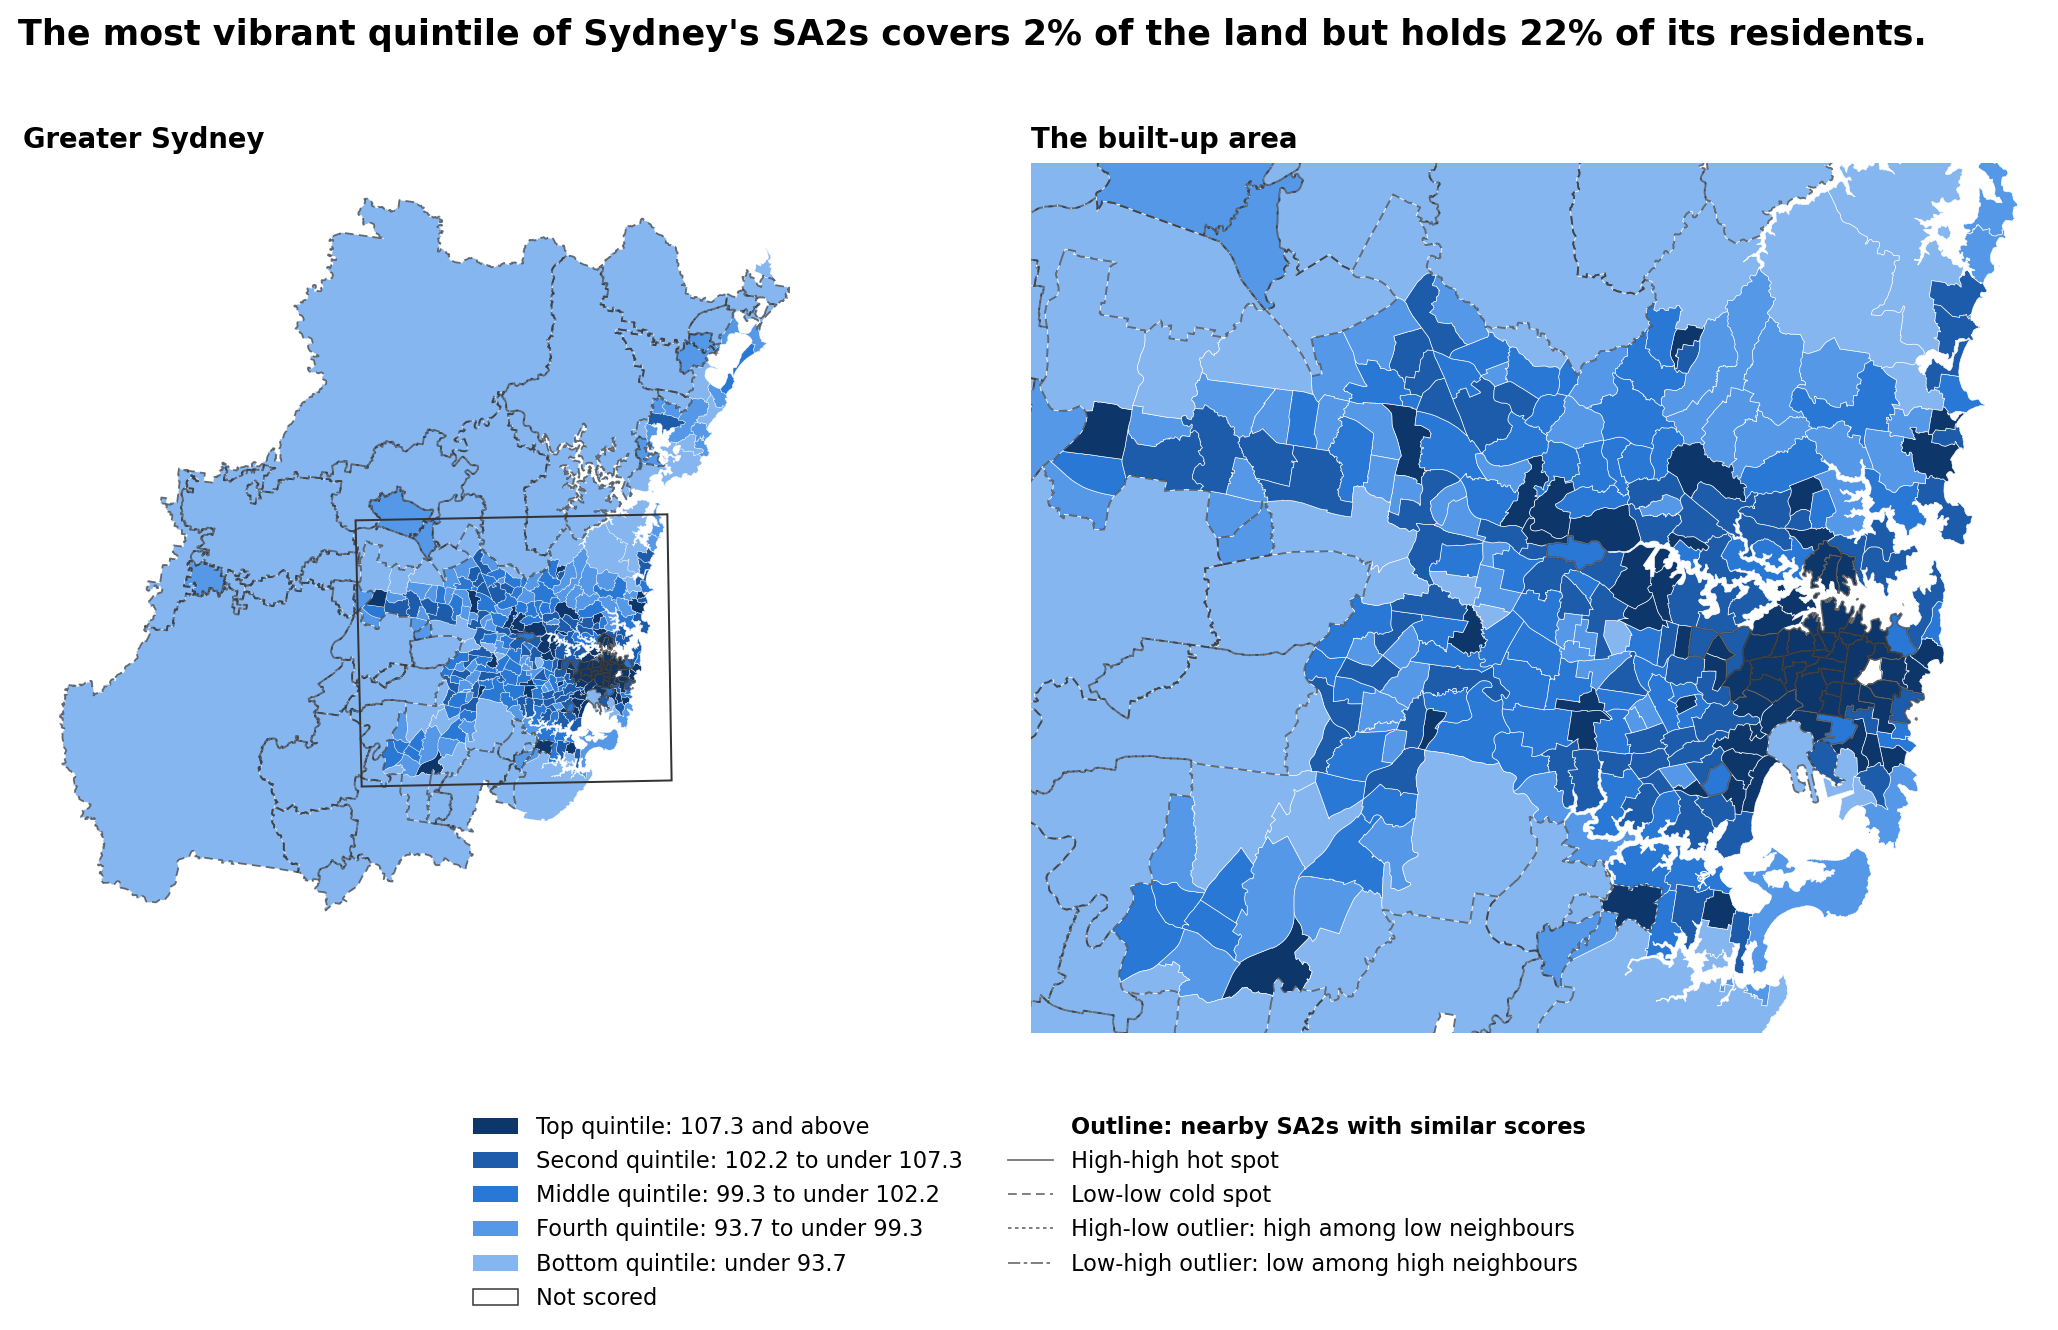

In [52]:
Image(filename=str(FIGURE_IMAGES / "vibrancy_map.png"))

Intensity on its own: darker blue where businesses, stops, residents and the other counts per area rank higher.

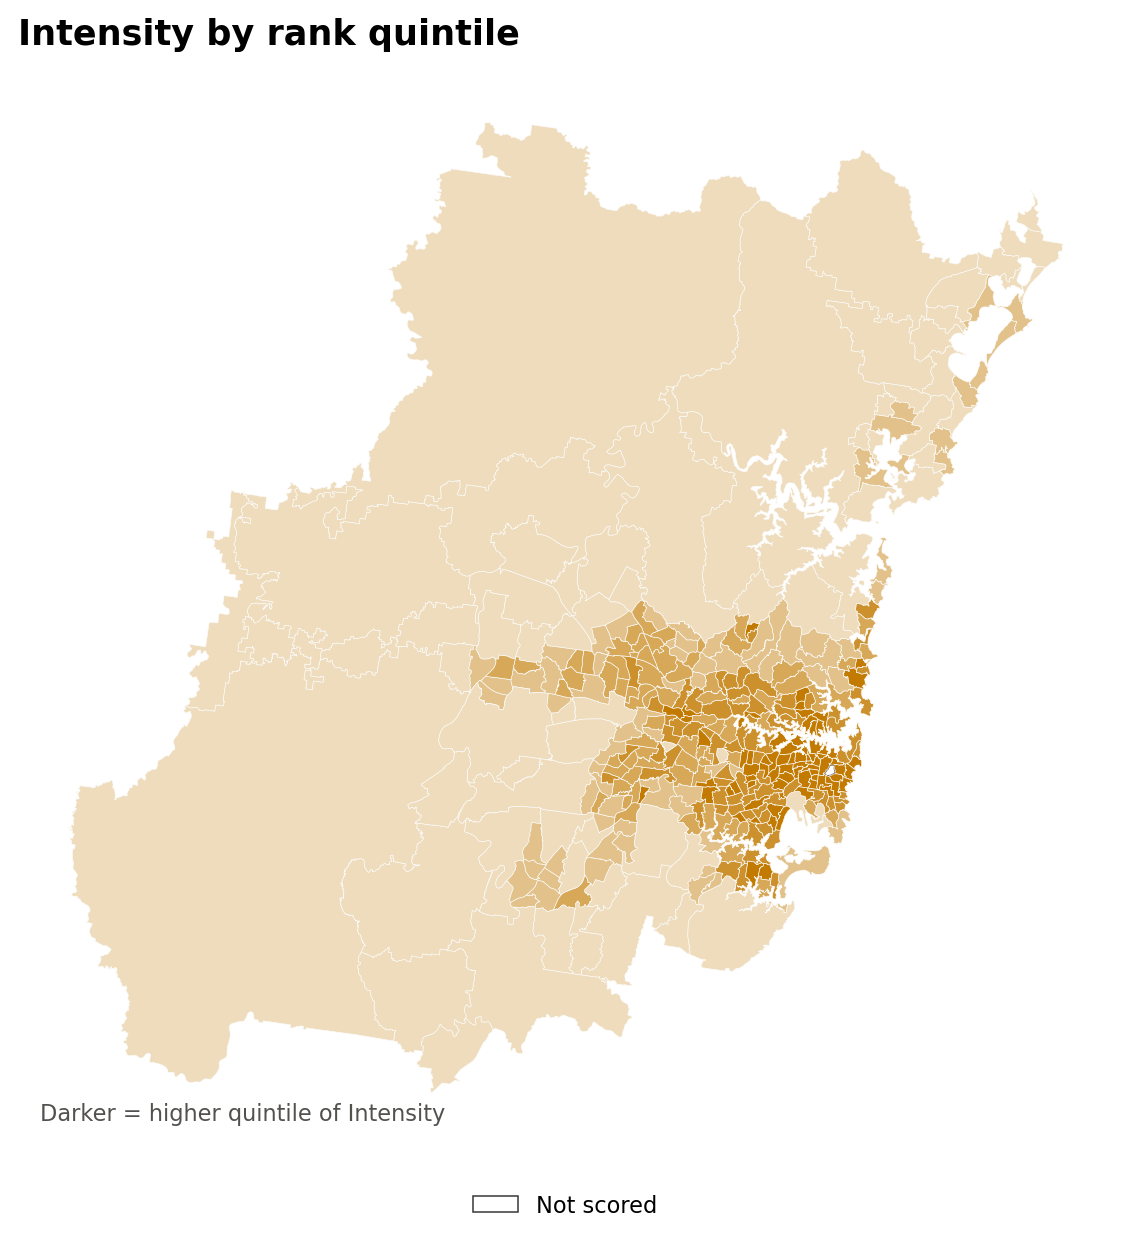

In [53]:
Image(filename=str(FIGURE_IMAGES / "vibrancy_intensity_map.png"))

Diversity on its own: darker blue where the mix of industries and land uses ranks higher.

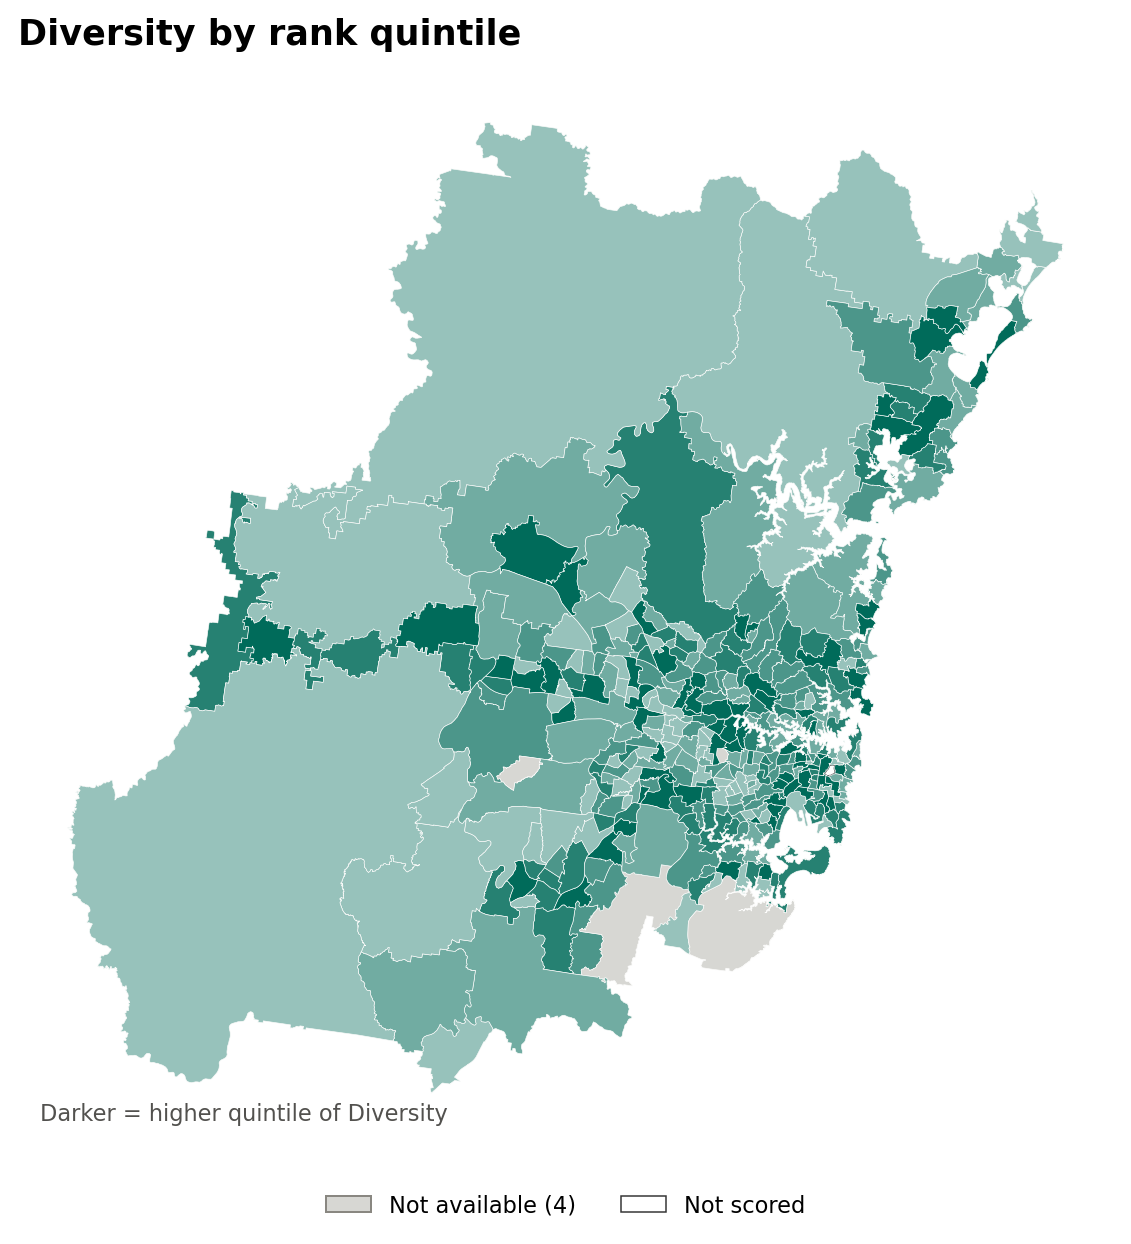

In [54]:
Image(filename=str(FIGURE_IMAGES / "vibrancy_diversity_map.png"))

Design on its own: darker blue where street intersections and crossings per area rank higher.

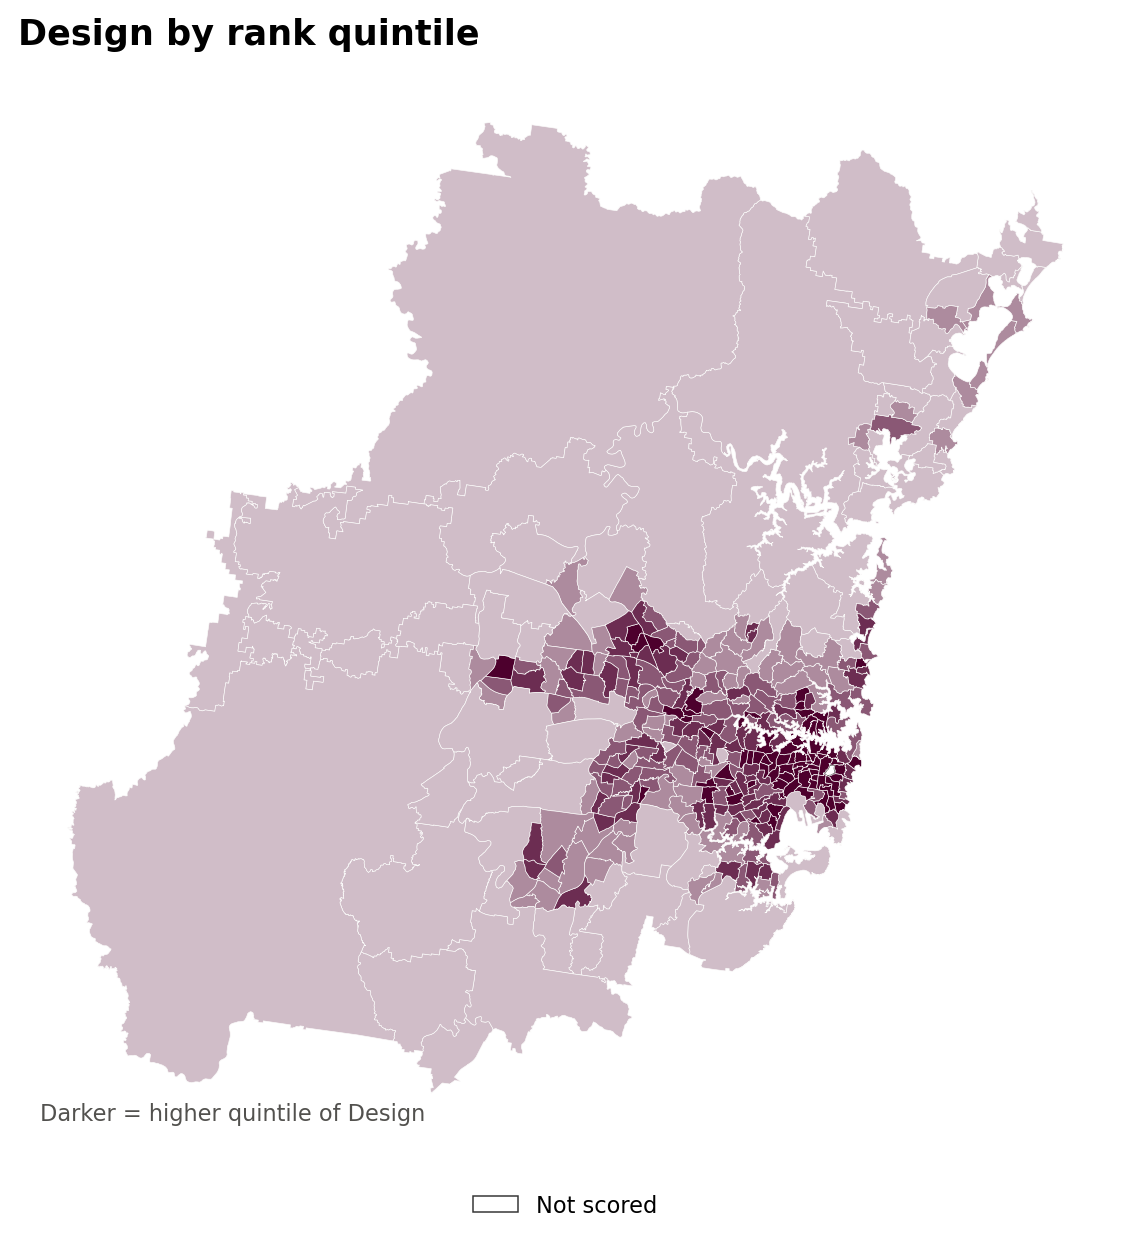

In [55]:
Image(filename=str(FIGURE_IMAGES / "vibrancy_design_map.png"))

The four kinds of place, from whether an SA2 is dense or less dense and diverse or less diverse.

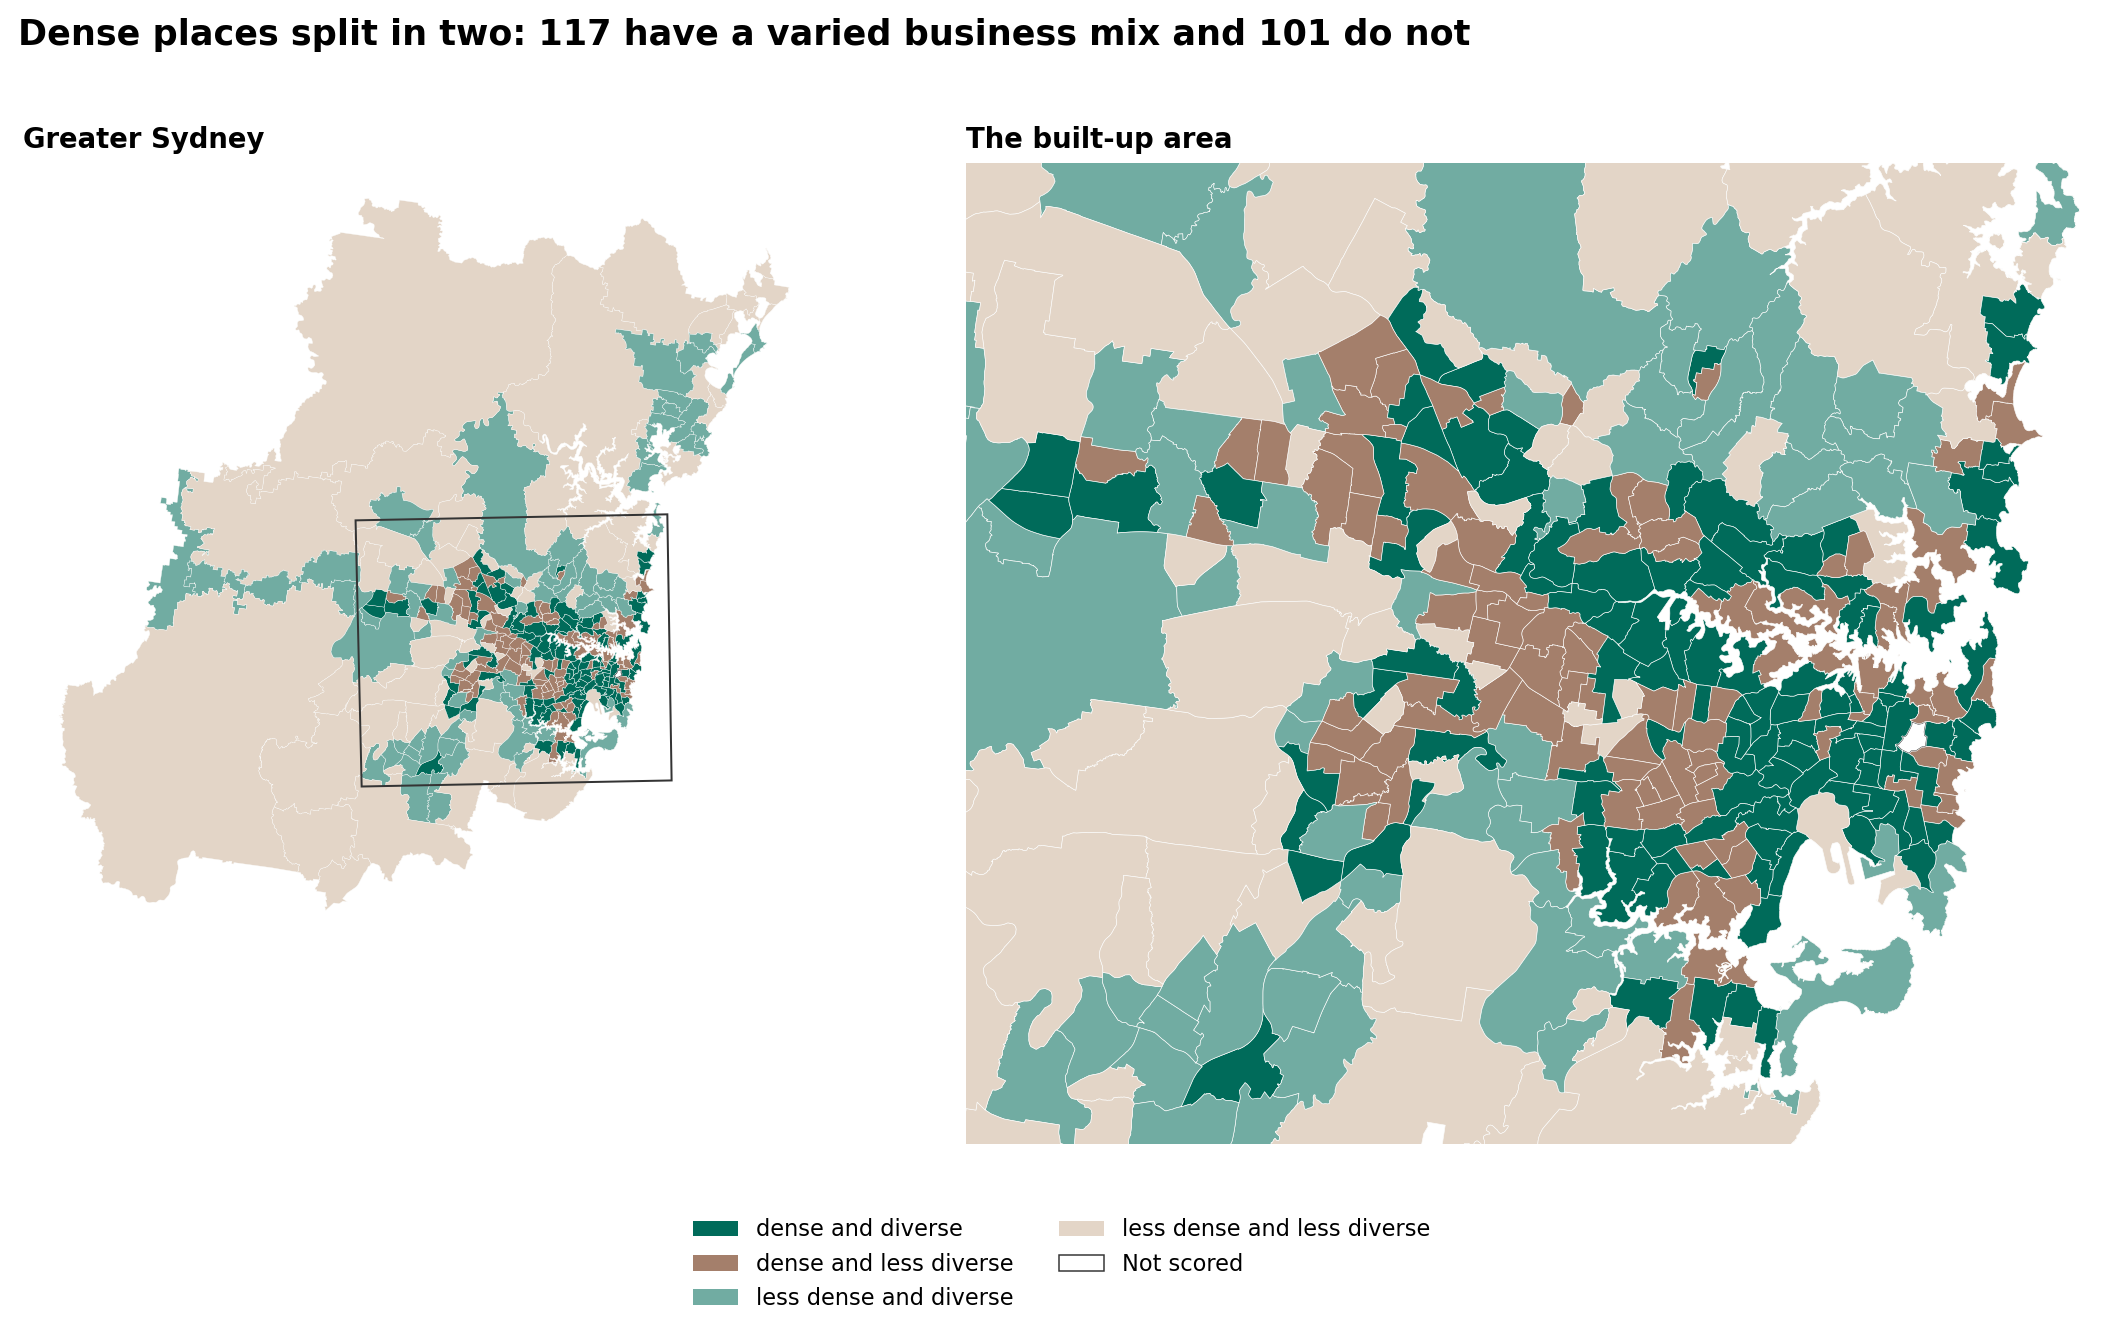

In [56]:
Image(filename=str(FIGURE_IMAGES / "vibrancy_place_types.png"))

The cluster map fills each SA2 by its local Moran's I class: high scores among high-scoring neighbours, low among low, the two kinds of outlier, and no cluster.

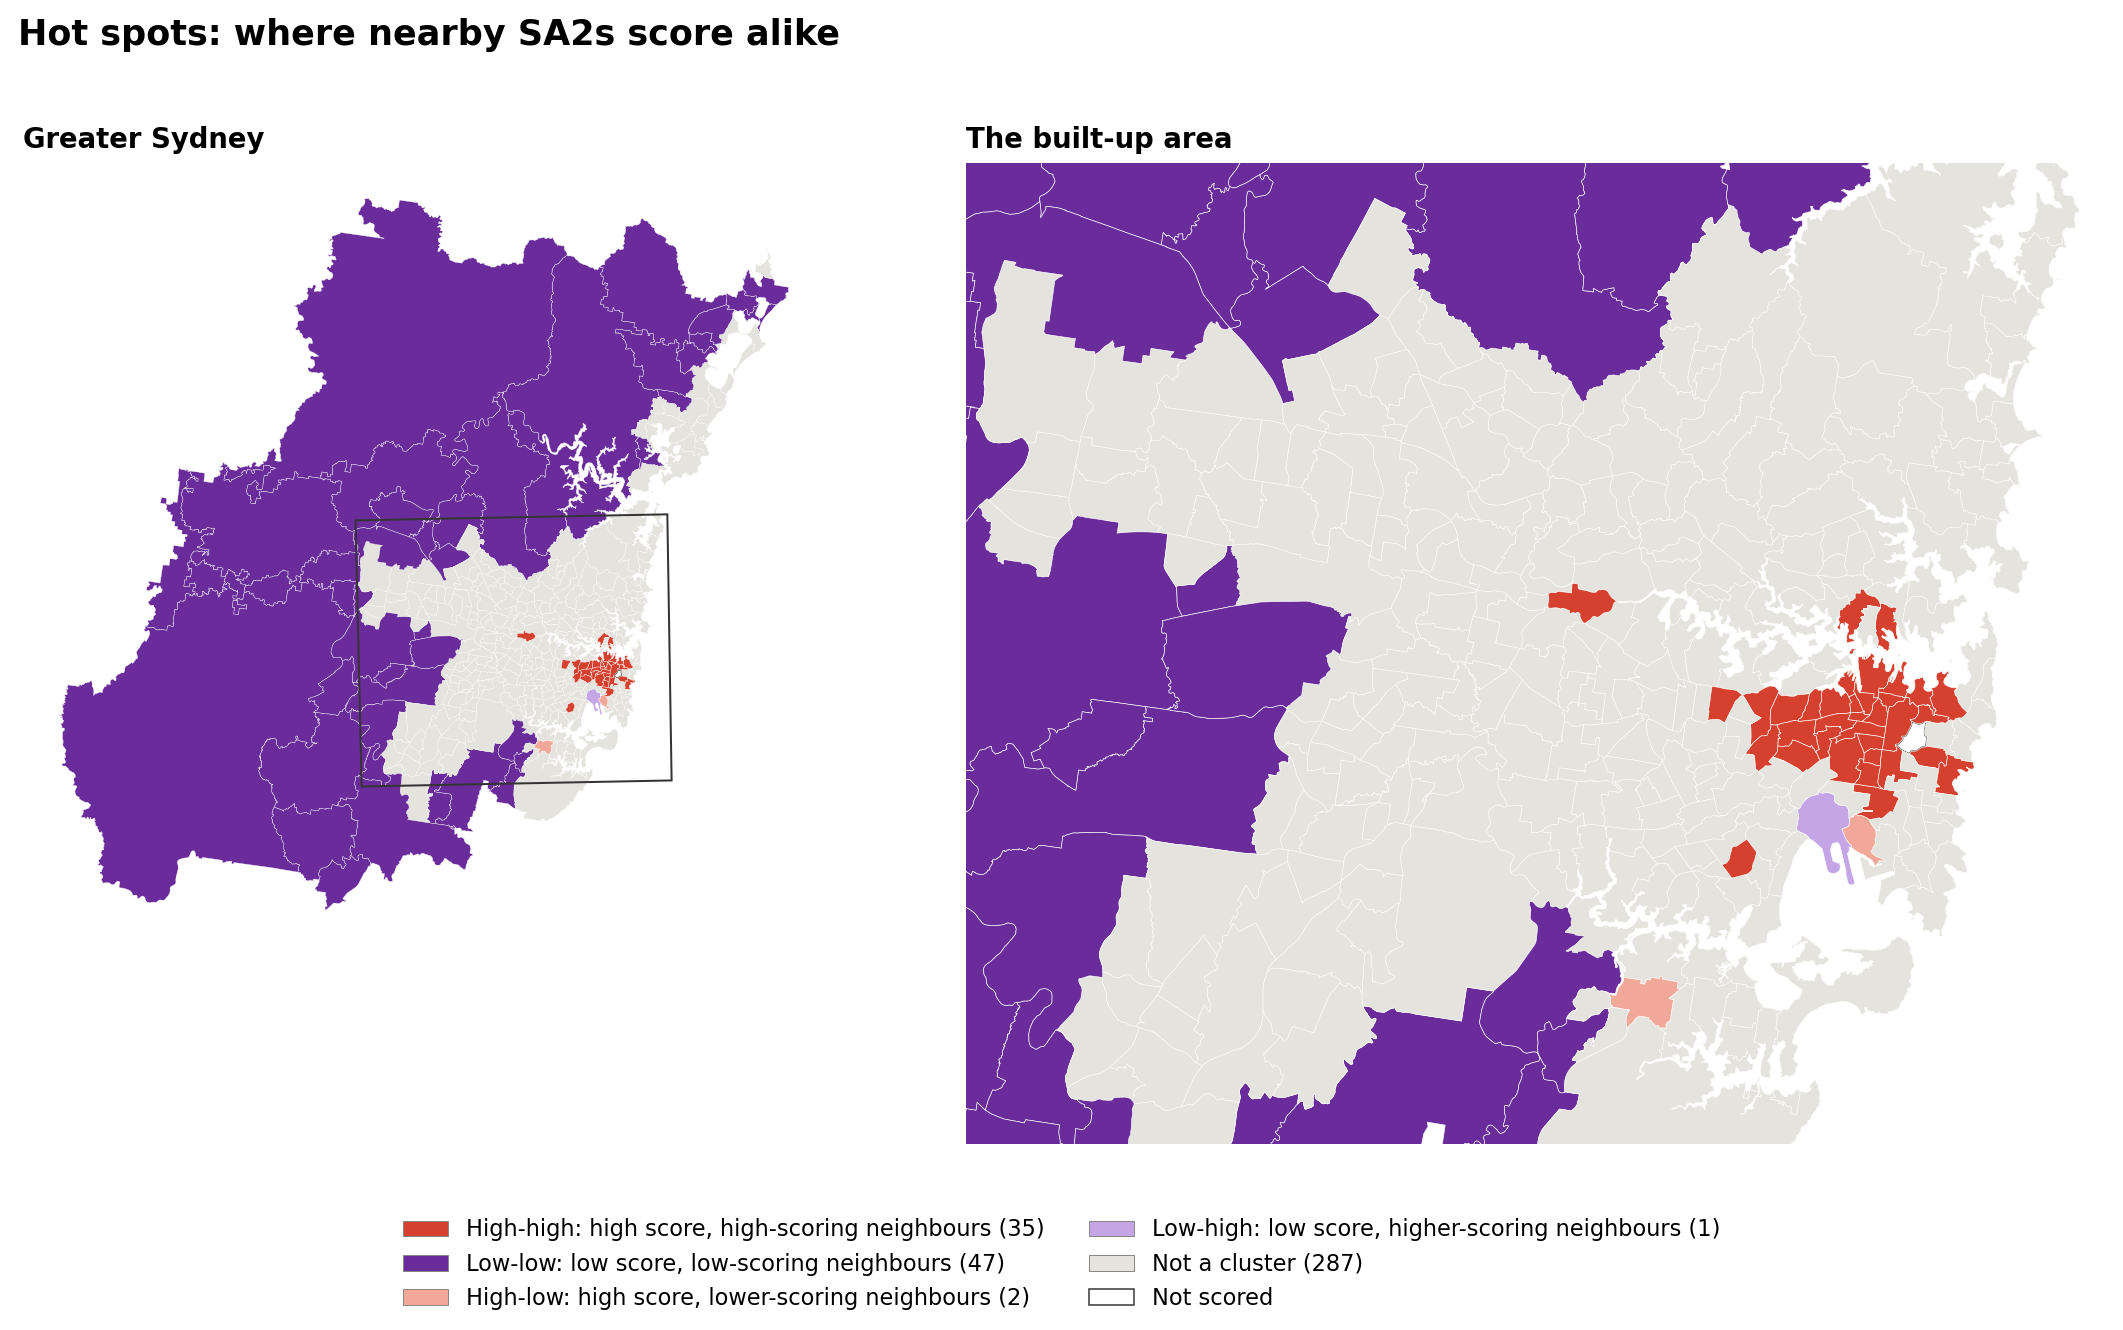

In [57]:
Image(filename=str(FIGURE_IMAGES / "vibrancy_hotspots.png"))

Each SA2's score against the average score of its neighbours: the line's slope is the global Moran's I, and the coloured dots are the clusters.

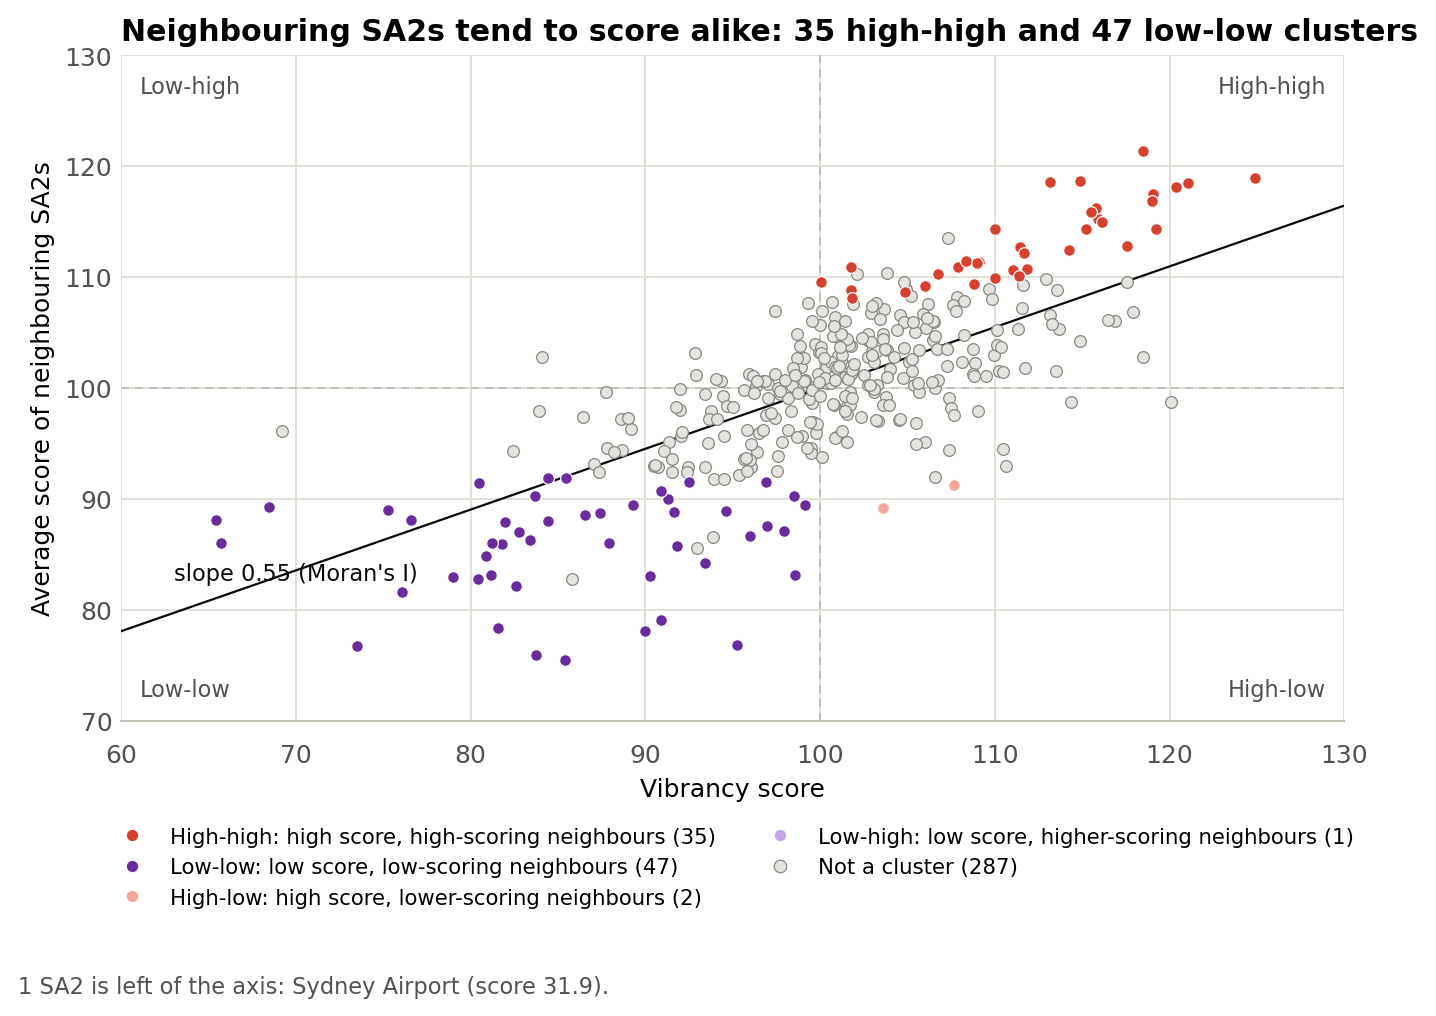

In [58]:
Image(filename=str(FIGURE_IMAGES / "vibrancy_moran.png"))

Vibrancy score against distance from the centre, with the average of 100 marked and a few outer exceptions named.

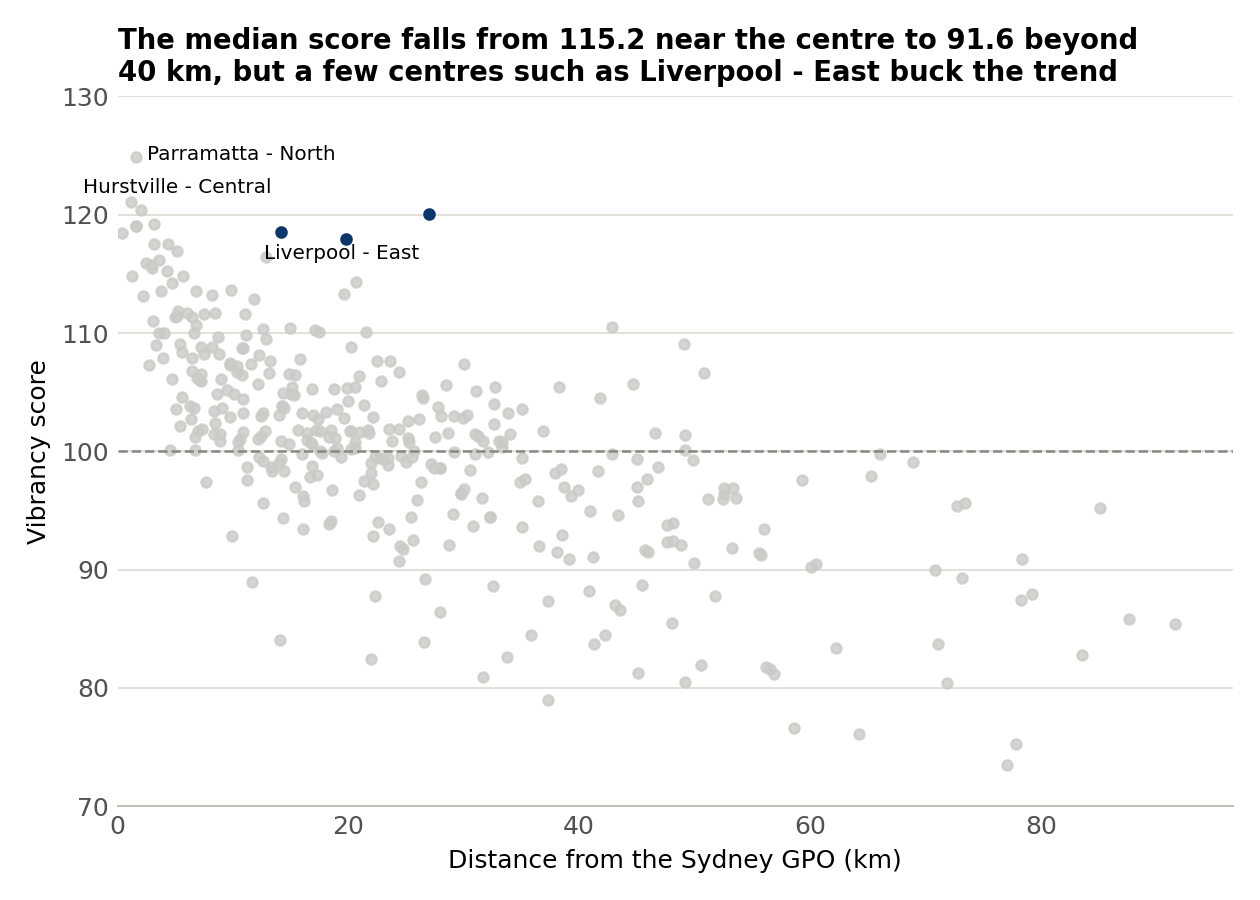

In [59]:
Image(filename=str(FIGURE_IMAGES / "vibrancy_distance.png"))

The share of each income group's residents who live in the top quintile (dark) and bottom quintile (grey) of SA2s.

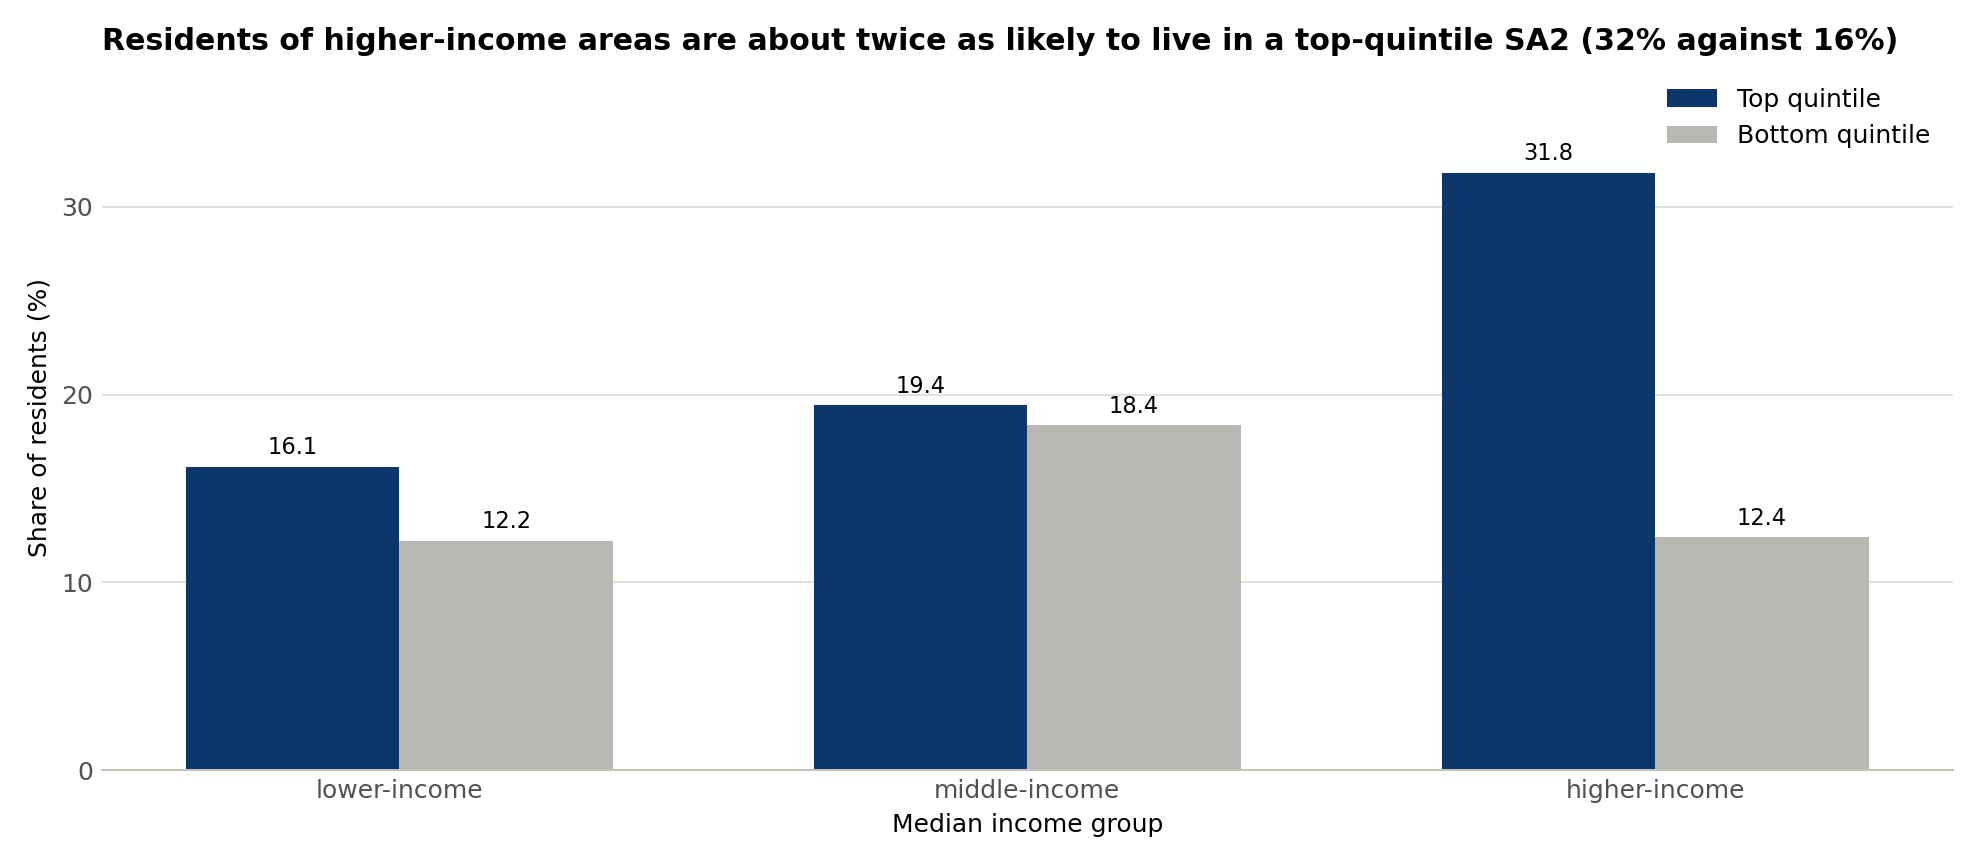

In [60]:
Image(filename=str(FIGURE_IMAGES / "vibrancy_equity.png"))

How far ranks move across the 22 sensitivity checks, by baseline rank band: the top and bottom hold still and the middle moves most.

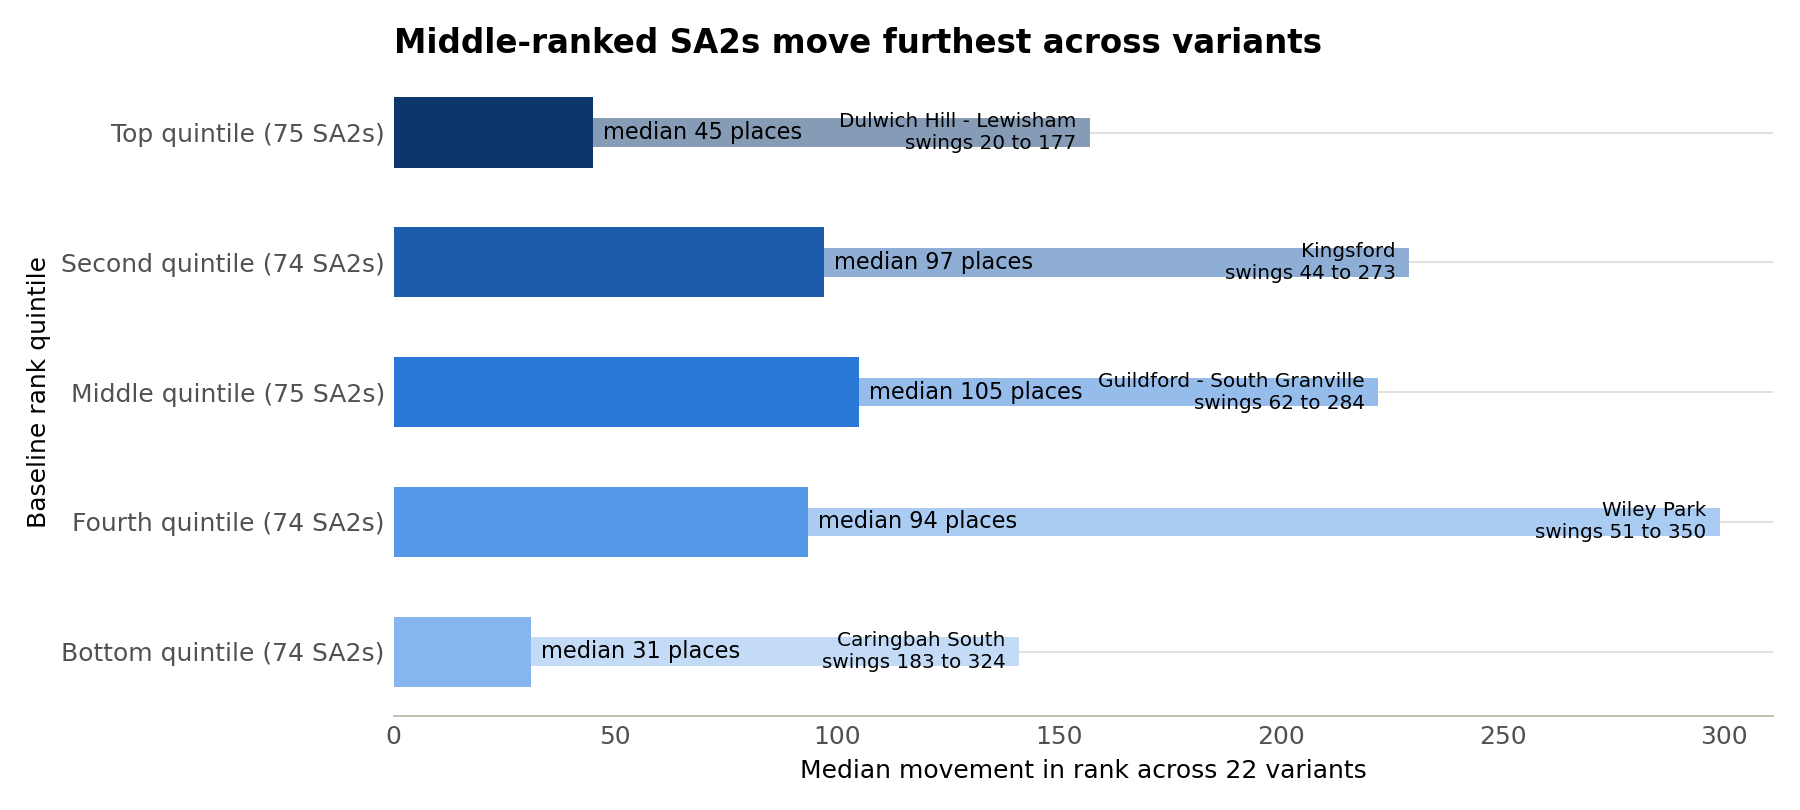

In [61]:
Image(filename=str(FIGURE_IMAGES / "vibrancy_rank_ranges.png"))

Weekday walking counts at the survey sites against the score of the SA2 they sit in, with the three busiest named.

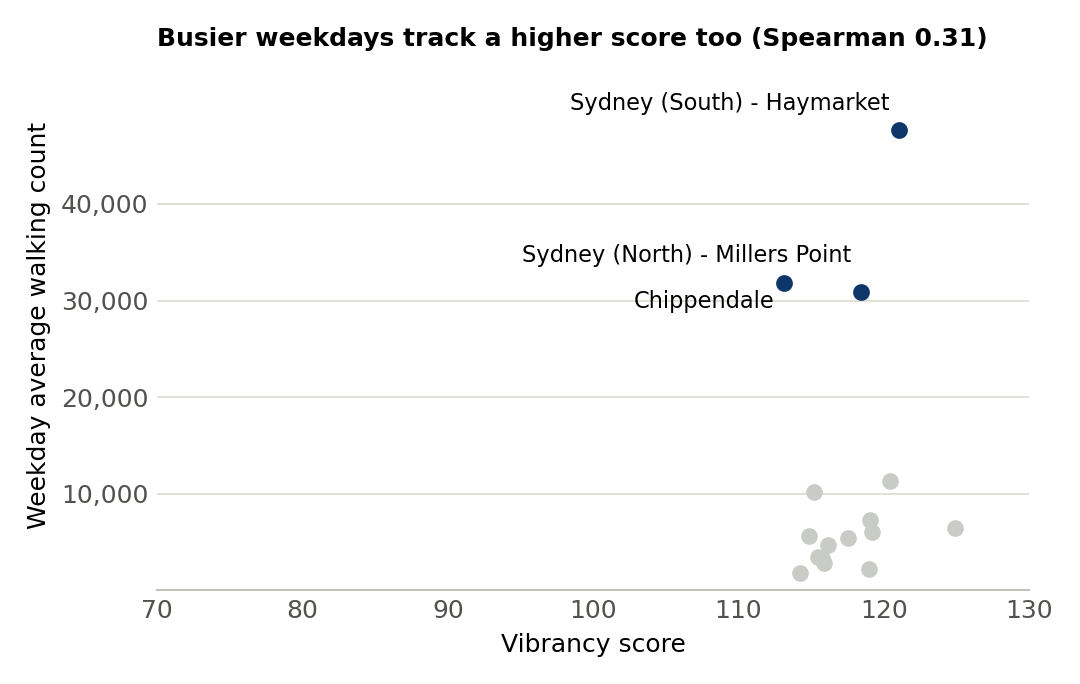

In [62]:
Image(filename=str(FIGURE_IMAGES / "vibrancy_foot_traffic_weekday.png"))

Weekend walking counts at the survey sites against the score of the SA2 they sit in, with the three busiest named.

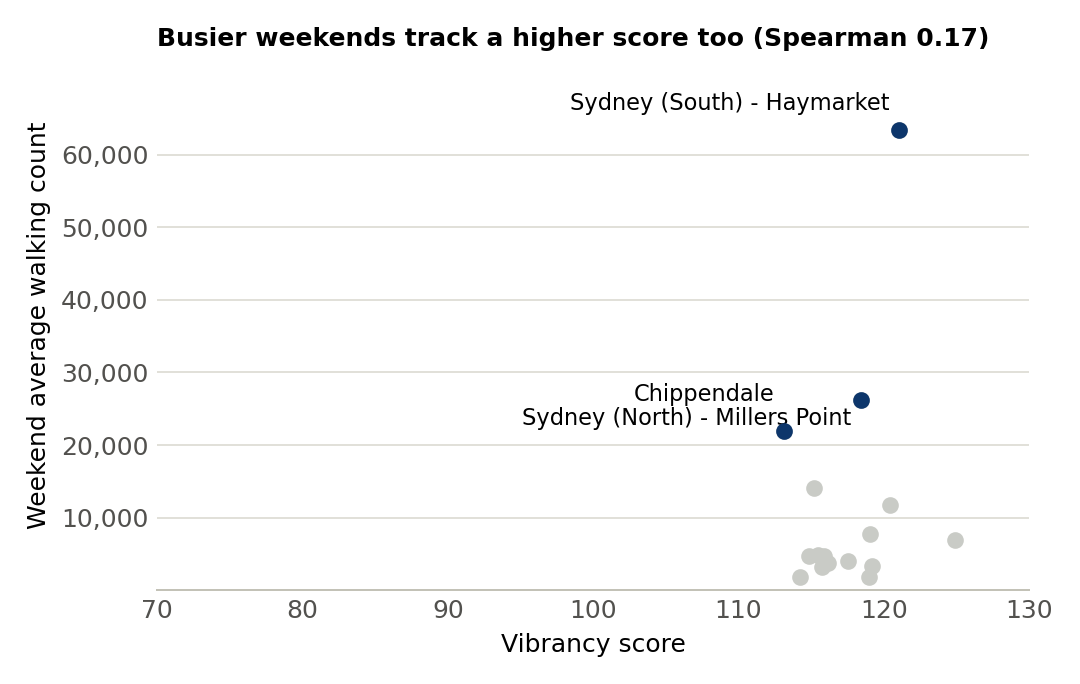

In [63]:
Image(filename=str(FIGURE_IMAGES / "vibrancy_foot_traffic_weekend.png"))